# MP2: Monthly activity and gaps — bdowlin2

## Sources and method

Historical commit details are strictly from WoC. All 83,535 successfully retrieved records are analyzed across the ten assigned projects. The TA approved analysis using reduced records; the user selected omission of the 54 unavailable WoC objects (OpenDA 7, GCAM 11, OpenMS 36). Their exact hashes and errors are documented in `bdowlin2_unavailable_woc_commits.csv` and `WOC_DATA_EXCEPTIONS.md`.

All historical metrics describe the retrieved records. Missing objects are excluded explicitly, never zero-filled or replaced with GitHub details. The seven unaffected projects have complete manifest coverage. `bdowlin2_collection_coverage.csv` reports expected, analyzed, and unavailable counts as proof of collection; seven projects exceed 1,000 analyzed records, and the other three have all their manifest records.

GitHub supplies stars/forks, the latest eligible commit and recent themes, and supplemental evidence. Status uses September 30, 2026 with April 1, 2026 as the six-month threshold, as selected by the user. Stars/forks are retrieval-time values. The live WoC data includes some 2026 commits; no uniform January 2025 snapshot is assumed. Counts span each project's first through last observed commit month, without trailing zero months.

## Definitions

Monthly counts span the first through last WoC commit month, including all intervening zero months. A longest gap is the longest run of zero months, even if it lasts fewer than three months. Ties use the earliest run. `NumberOfGapsInTimeline` counts runs lasting at least three months. `NumCommitsAfterLastGap` follows the README definition: commits after the **longest** gap, despite the field name. A project without a zero month has gap length 0 and N/A gap dates. No trailing inactivity is appended beyond the last observed WoC commit.

Pre/post samples are the final ten commits before and first ten after the longest gap, or all available if fewer. Ties in timestamps are sorted by SHA for reproducibility. Gap recovery means an observed post-gap commit, not proof of sustained maintenance. Current status is assessed independently using GitHub and the September 30, 2026 cutoff.

In [1]:
from pathlib import Path
import os
import pandas as pd
from IPython.display import display, Image
ROOT = Path(os.environ.get('MP2_ROOT', Path.cwd()))
NETID = 'bdowlin2'
FIELDS = ['project_wocid','commit_sha1','author','time','commit message']
EXPECTED = {'avehtari_bda_course_aalto': 2272, 'eberharf_cfl': 1138, 'inqwire_sqir': 1338, 'jayggg_ngstents': 454, 'jgcri_gcam-core': 10677, 'openda-association_openda': 3202, 'openms_openms': 54828, 'tee-lab_pyddsde': 233, 'vatlab_sos': 8834, 'windweller_disextract': 559}
MANIFEST_EXPECTED = {'avehtari_bda_course_aalto': 2272, 'eberharf_cfl': 1138, 'openda-association_openda': 3209, 'openms_openms': 54864, 'vatlab_sos': 8834, 'jayggg_ngstents': 454, 'inqwire_sqir': 1338, 'tee-lab_pyddsde': 233, 'jgcri_gcam-core': 10688, 'windweller_disextract': 559}
OMITTED_SHA = {'avehtari_bda_course_aalto': [], 'eberharf_cfl': [], 'openda-association_openda': ['140121a8ec865bd6a0539c1618a5d2c142077e2d', '2a5674f7f773bf3f43496b4bf2e192de6770d9b7', '3683de7c2f1429beb45cac1921e3ccb5c82a3fa3', '44d0265855202b620b9ee3c9693e1ae03b680ef2', '6ea4b2ae8de635925c178f85262b69ae634a188a', '77c33ed192154c33d469abd3303fa75d8d1b4a7a', 'd137c7ad44156395ad6f27fb842c9528bce759a5'], 'openms_openms': ['129b8131f794cace10ad2ec3ce15042913a29581', '36999e78fe2d28e407a9f8f9e373a4fdbcea4add', '3ca10ef8b9dbaed2e620fcc886268495eb07fd70', '3db4de6ee30642be1ce2bbbe1f40c959bc399156', '4309527d3ba0e06baef2c61388bc4b37370cef1b', '4b7e74f50c55fd726b59de3e704a652475196137', '4c0a1c0bf4abe4e33119b6d509f5224130b85303', '520c2b0004518ff45988795b5335259359e23329', '5290369051952f1a445819649dcf60b98e459471', '55a7cbd29832b4308864f1dd88a21584f04df0fb', '5830392f5f774d8d8980d065395f37e8e77e6a21', '5af760a981893537f9c272cff13ca8f384533815', '5b5462d0aec8f9671e13ac5d6f0d4ab96765db99', '5c417fdcbe753cbf93a61d2c39b4890f35dbcecd', '6221cf80e1cfe2524b43bdf707578749070dfea6', '6ff496b5610c628486cc8065f49353875bd01807', '7b6d2d0d4a32ead2faa47ef1db097f8cdb7f807f', '7e3ba0839397164099c820d11ea5f7c60f82129a', '7ec2ea449b3da34f0a438e07de84bd5b2833e526', '7ec33827661b1e58cdaacb5ab2c4fdbbd5a4324d', '7f23ad8a236f406078e5d48746b61f13121b9dc9', '8152c0497a6bf9e62188102d5baebce67733907d', '815ce502bd97f548976d486a479817c0777318b6', '92a6a40e96358ff2f2ad63bc359e9adf29f1c813', '9d6ef6edcfd9c383017c4305093be04589cfce99', 'a1e0845cbe6125cbe93e79657ac9d0cecd06655c', 'a49e1d962709ae0f705d1ff93b2baeec2876497f', 'ae70bcc0ce460fff5735a8ac6f05d0ef2214a39c', 'b24e005a0e61fdde6ab798d4dba45353b7a92fa0', 'd6ef4de7603ae6be56a4a4f3cd01205f62d0bc15', 'd946a13a92b8fef08d5338243bf6328b1744ed79', 'e5d5cb5b30f988dc208409df79532879ce27dcf3', 'e8cc8894d6c71f4b747df9f3923c885cdbb39196', 'f59a014a80cca719a10f6d4ee0980b24672cc0a4', 'fb836abbe616ba1c7f1a686a3e267af63aa83b30', 'ff146b473baa0d9c57c265e4cb02cfd33f9f1373'], 'vatlab_sos': [], 'jayggg_ngstents': [], 'inqwire_sqir': [], 'tee-lab_pyddsde': [], 'jgcri_gcam-core': ['0932cec7bf6dcfb73b5b4959d4ff5acea8ffe839', '0f73ec81b518038c30084f53dd0828bda4dd323d', '2c18636e69b27ebac8950fe16ce9e25fa0685a49', '3214af619327a9d1f77b10087f56e368adb7b3ba', '32b0b0e6253f3bc41129209ef8bf338cf1a8bbda', '6c4823bd3d4bb1ef5d8348c92d94860c7fabe40e', '70ec8bb344c7a849abf76fc477445dcc5a7c3611', '7565d844d2542fe8b54dc2a1ec9319397bd01904', '7cbcf67c0b0bf2506ff7e707556c296aa34b6c8d', '93ba023ab030d5e4a8a51360e971c52c1aeb5737', 'd73e681e97086a076aa3e4a3b880f6b36f1cc95a'], 'windweller_disextract': []}

def read_submission():
    data = pd.read_csv(ROOT / 'bdowlin2_project_summary.csv', sep=';', keep_default_na=False,
                       dtype={'project_wocid':str,'commit_sha1':str,'author':str,'time':'int64','commit message':str})
    assert list(data.columns) == FIELDS
    assert not data.duplicated(['project_wocid','commit_sha1']).any()
    assert data.author.ne('').all() and data.commit_sha1.str.fullmatch('[0-9a-f]{40}').all()
    assert set(data.project_wocid) == set(EXPECTED)
    for name, part in data.groupby('project_wocid'):
        assert len(part) == EXPECTED[name], f'Unexpected analyzed count: {name}'
        assert EXPECTED[name] + len(OMITTED_SHA[name]) == MANIFEST_EXPECTED[name]
        assert not set(part.commit_sha1) & set(OMITTED_SHA[name])
    data['date'] = pd.to_datetime(data.time, unit='s', utc=True)
    return data

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
summary = read_submission()
ready = True
print('Submitted records:', len(summary), 'across', summary.project_wocid.nunique(), 'analyzed projects')

def zero_runs(counts):
    runs=[]; start=None
    for i,value in enumerate(list(counts)+[1]):
        if value==0 and start is None: start=i
        elif value!=0 and start is not None:
            runs.append((start,i-1,i-start)); start=None
    return runs


Could not save font_manager cache [Errno 13] Permission denied: 'C:\\Users\\brett\\.matplotlib\\fontlist-v3.11.0.json.matplotlib-lock'


Submitted records: 83535 across 10 analyzed projects


In [2]:
stats = pd.read_csv(ROOT / 'bdowlin2_project_stats.csv', sep=';', keep_default_na=False).set_index('Project')
gap_rows=[]
for name,g in summary.groupby('project_wocid',sort=False):
    g=g.sort_values(['time','commit_sha1'])
    months=g.date.dt.tz_localize(None).dt.to_period('M')
    counts=months.value_counts().sort_index()
    counts=counts.reindex(pd.period_range(counts.index.min(),counts.index.max(),freq='M'),fill_value=0)
    pd.DataFrame({'Month':counts.index.astype(str),'#Commits':counts.values}).to_csv(
        ROOT/f'bdowlin2_commits_timeseries_{name}.csv',sep=';',index=False)
    assert counts.sum()==len(g)
    runs=zero_runs(counts.values)
    longest=max(runs,key=lambda run:run[2]) if runs else None # Earliest tied run wins.
    computed={'ncommits':len(g),'nauthors':g.author.nunique(),'from':g.date.min().isoformat(),
              'to':g.date.max().isoformat(),'NumberOfGapsInTimeline':sum(run[2]>=3 for run in runs),
              'LongestGapStart':'N/A','LongestGapEnd':'N/A','LongestGapLength':0,'NumCommitsAfterLastGap':'N/A'}
    if longest:
        a,b,length=longest; start=counts.index[a]; end=counts.index[b]
        computed.update(LongestGapStart=str(start),LongestGapEnd=str(end),LongestGapLength=length,
                        NumCommitsAfterLastGap=int(counts.iloc[b+1:].sum()))
        before=g[g.date<pd.Timestamp(start.start_time,tz='UTC')].tail(10)
        after=g[g.date>=pd.Timestamp((end+1).start_time,tz='UTC')].head(10)
        for side,part in [('pre',before),('post',after)]:
            gap_rows.extend({'pre/post':side,**row} for row in part[FIELDS].to_dict('records'))
    for key,value in computed.items():
        existing=stats.loc[name,key]
        if key in ['ncommits','nauthors','NumberOfGapsInTimeline','LongestGapLength']:
            assert int(existing)==value, (name,key,existing,value)
        else:
            assert str(existing)==str(value), (name,key,existing,value)
    fig,ax=plt.subplots(figsize=(11,5))
    ax.plot(counts.index.to_timestamp(),counts.values,lw=1.3,color='#245b8a')
    if longest:
        ax.axvspan(start.start_time,(end+1).start_time,color='#e6b95d',alpha=.25,label=f'Longest gap: {length} months')
        ax.legend(frameon=False)
    ax.set(title=name,xlabel='Month (YYYY-MM)',ylabel='Number of commits')
    ax.grid(True,alpha=.25);ax.set_ylim(bottom=0)
    ax.xaxis.set_major_locator(mdates.AutoDateLocator(minticks=5,maxticks=10))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    fig.autofmt_xdate();fig.tight_layout()
    fig.savefig(ROOT/f'bdowlin2_timeseries_{name}.png',dpi=300);plt.close(fig)
pd.DataFrame(gap_rows,columns=['pre/post']+FIELDS).to_csv(ROOT/'bdowlin2_project_gap_commits.csv',sep=';',index=False)
stats=stats.loc[list(summary.project_wocid.unique())].reset_index()
display(stats)
print('Quantitative fields agree with the submitted statistics. Reviewed interpretations are preserved.')


,Project,ncommits,nauthors,from,to,nstars,nforks,lastGHCommitDate,LongestGapStart,LongestGapEnd,...,RecentThemes,Notes,WoCDataComplete,GapReviewComplete,AnalysisComplete,StatusAsOf,WoCExpectedCommits,WoCMissingCommits,WoCCoveragePercent,DataBasis
0,avehtari_bda_course_aalto,2272,67,2018-09-07T14:11:11+00:00,2025-11-03T15:40:44+00:00,2282,566,2026-09-29T11:32:50Z,2025-02,2025-06,...,Documentation updates:Other,The course repository has a cyclical trajector...,True,True,True,2026-09-30,2272,0,100.0000,Complete WoC manifest
1,eberharf_cfl,1138,14,2020-07-17T21:53:13+00:00,2025-05-07T22:32:37+00:00,19,1,2026-05-05T21:52:43Z,2022-05,2023-11,...,Other:Dependency updates,CFL has a declining trajectory and two gaps of...,True,True,True,2026-09-30,1138,0,100.0000,Complete WoC manifest
2,inqwire_sqir,1338,34,2018-12-20T22:11:21+00:00,2025-07-30T02:27:23+00:00,105,26,2025-07-30T02:27:23Z,2023-06,2023-12,...,Feature development:Other,SQIR has a declining overall trajectory with f...,True,True,True,2026-09-30,1338,0,100.0000,Complete WoC manifest
3,jayggg_ngstents,454,11,2020-06-29T20:41:15+00:00,2025-06-10T12:50:41+00:00,9,6,2025-11-27T00:17:25Z,2022-04,2023-05,...,Other:Documentation updates,The project has a declining overall trajectory...,True,True,True,2026-09-30,454,0,100.0000,Complete WoC manifest
4,jgcri_gcam-core,10677,161,2002-10-14T17:48:16+00:00,2026-04-01T20:36:00+00:00,432,226,2026-06-01T21:04:27Z,2008-07,2008-08,...,Feature development:Bug fixes,GCAM has irregular activity across several pha...,False,True,True,2026-09-30,10688,11,99.8971,Retrieved WoC records; TA-approved omissions
5,openda-association_openda,3202,63,2014-09-24T12:58:34+00:00,2025-10-22T13:02:45+00:00,104,34,2026-07-10T13:57:20Z,2014-10,2015-02,...,Documentation updates:Feature development,OpenDA has irregular monthly activity and one ...,False,True,True,2026-09-30,3209,7,99.7819,Retrieved WoC records; TA-approved omissions
6,openms_openms,54828,538,2006-06-11T05:48:53+00:00,2026-04-17T10:04:15+00:00,623,445,2026-09-30T17:00:08Z,N/A,N/A,...,Bug fixes:Documentation updates,OpenMS has a rising overall activity trajector...,False,True,True,2026-09-30,54864,36,99.9344,Retrieved WoC records; TA-approved omissions
7,tee-lab_pyddsde,233,7,2020-03-30T14:40:44+00:00,2021-10-29T06:08:17+00:00,98,12,2026-06-10T04:11:37Z,2020-10,2020-11,...,Documentation updates:Bug fixes,The WoC timeline is irregular and has no gaps ...,True,True,True,2026-09-30,233,0,100.0000,Complete WoC manifest
8,vatlab_sos,8834,55,2016-02-13T00:46:46+00:00,2025-11-06T14:29:35+00:00,286,44,2026-09-09T18:36:17Z,2024-11,2025-08,...,Dependency updates:Bug fixes,SoS has a declining overall trajectory despite...,True,True,True,2026-09-30,8834,0,100.0000,Complete WoC manifest
9,windweller_disextract,559,9,2017-10-29T23:56:48+00:00,2025-07-13T15:34:42+00:00,0,0,2025-07-13T15:34:42Z,2020-04,2025-06,...,Other,The declining timeline contains two gaps of at...,True,True,True,2026-09-30,559,0,100.0000,Complete WoC manifest


Quantitative fields agree with the submitted statistics. Reviewed interpretations are preserved.


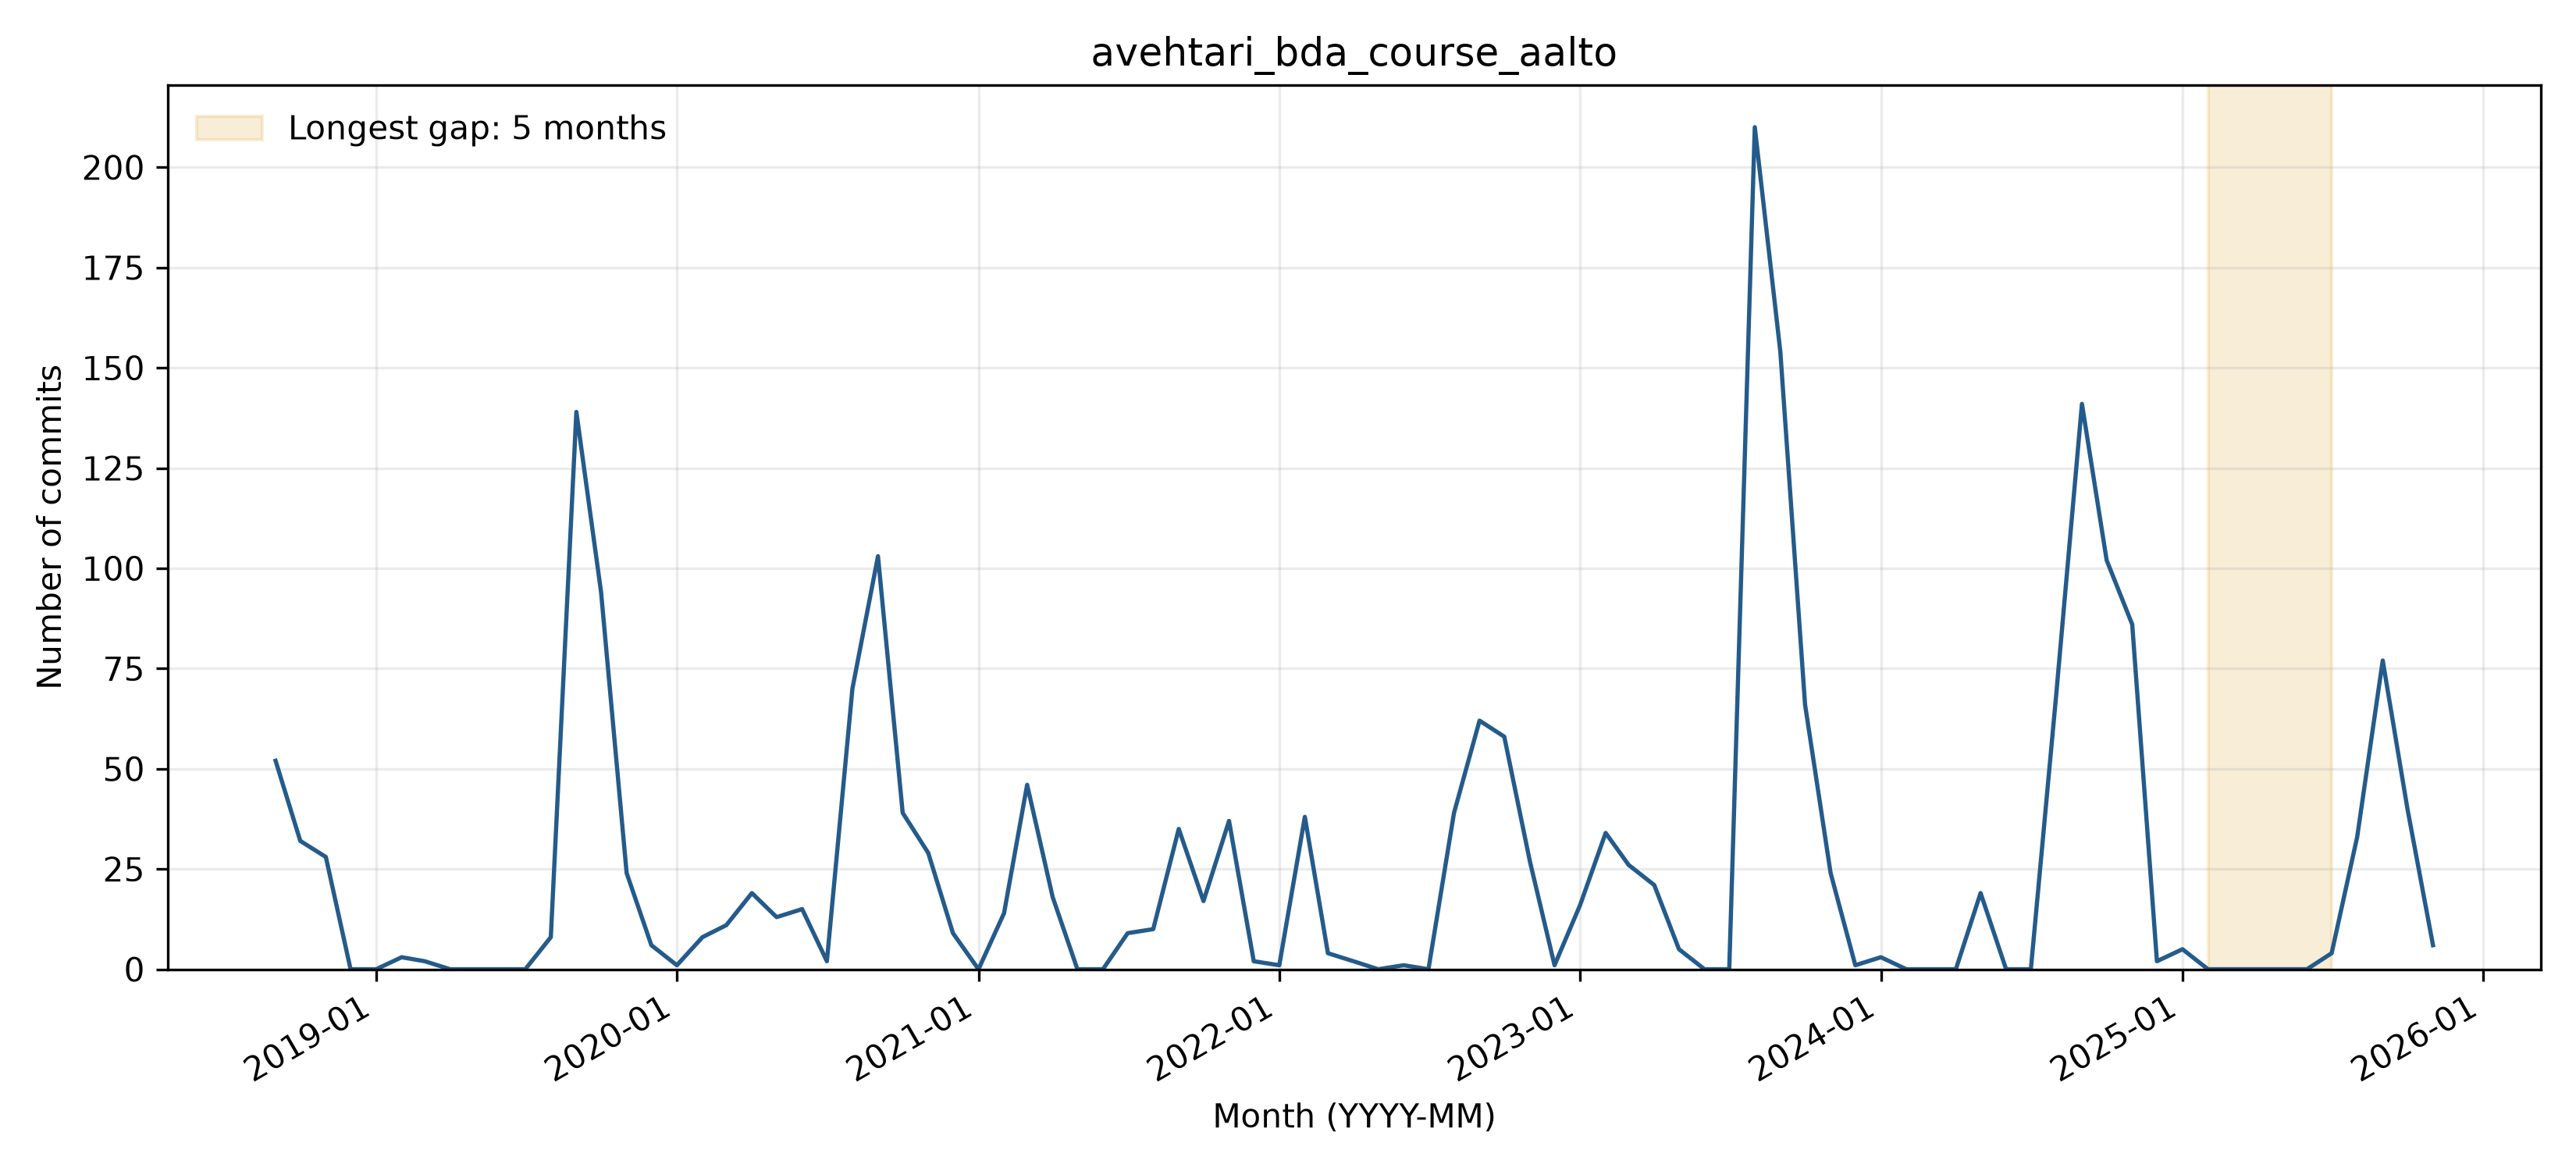

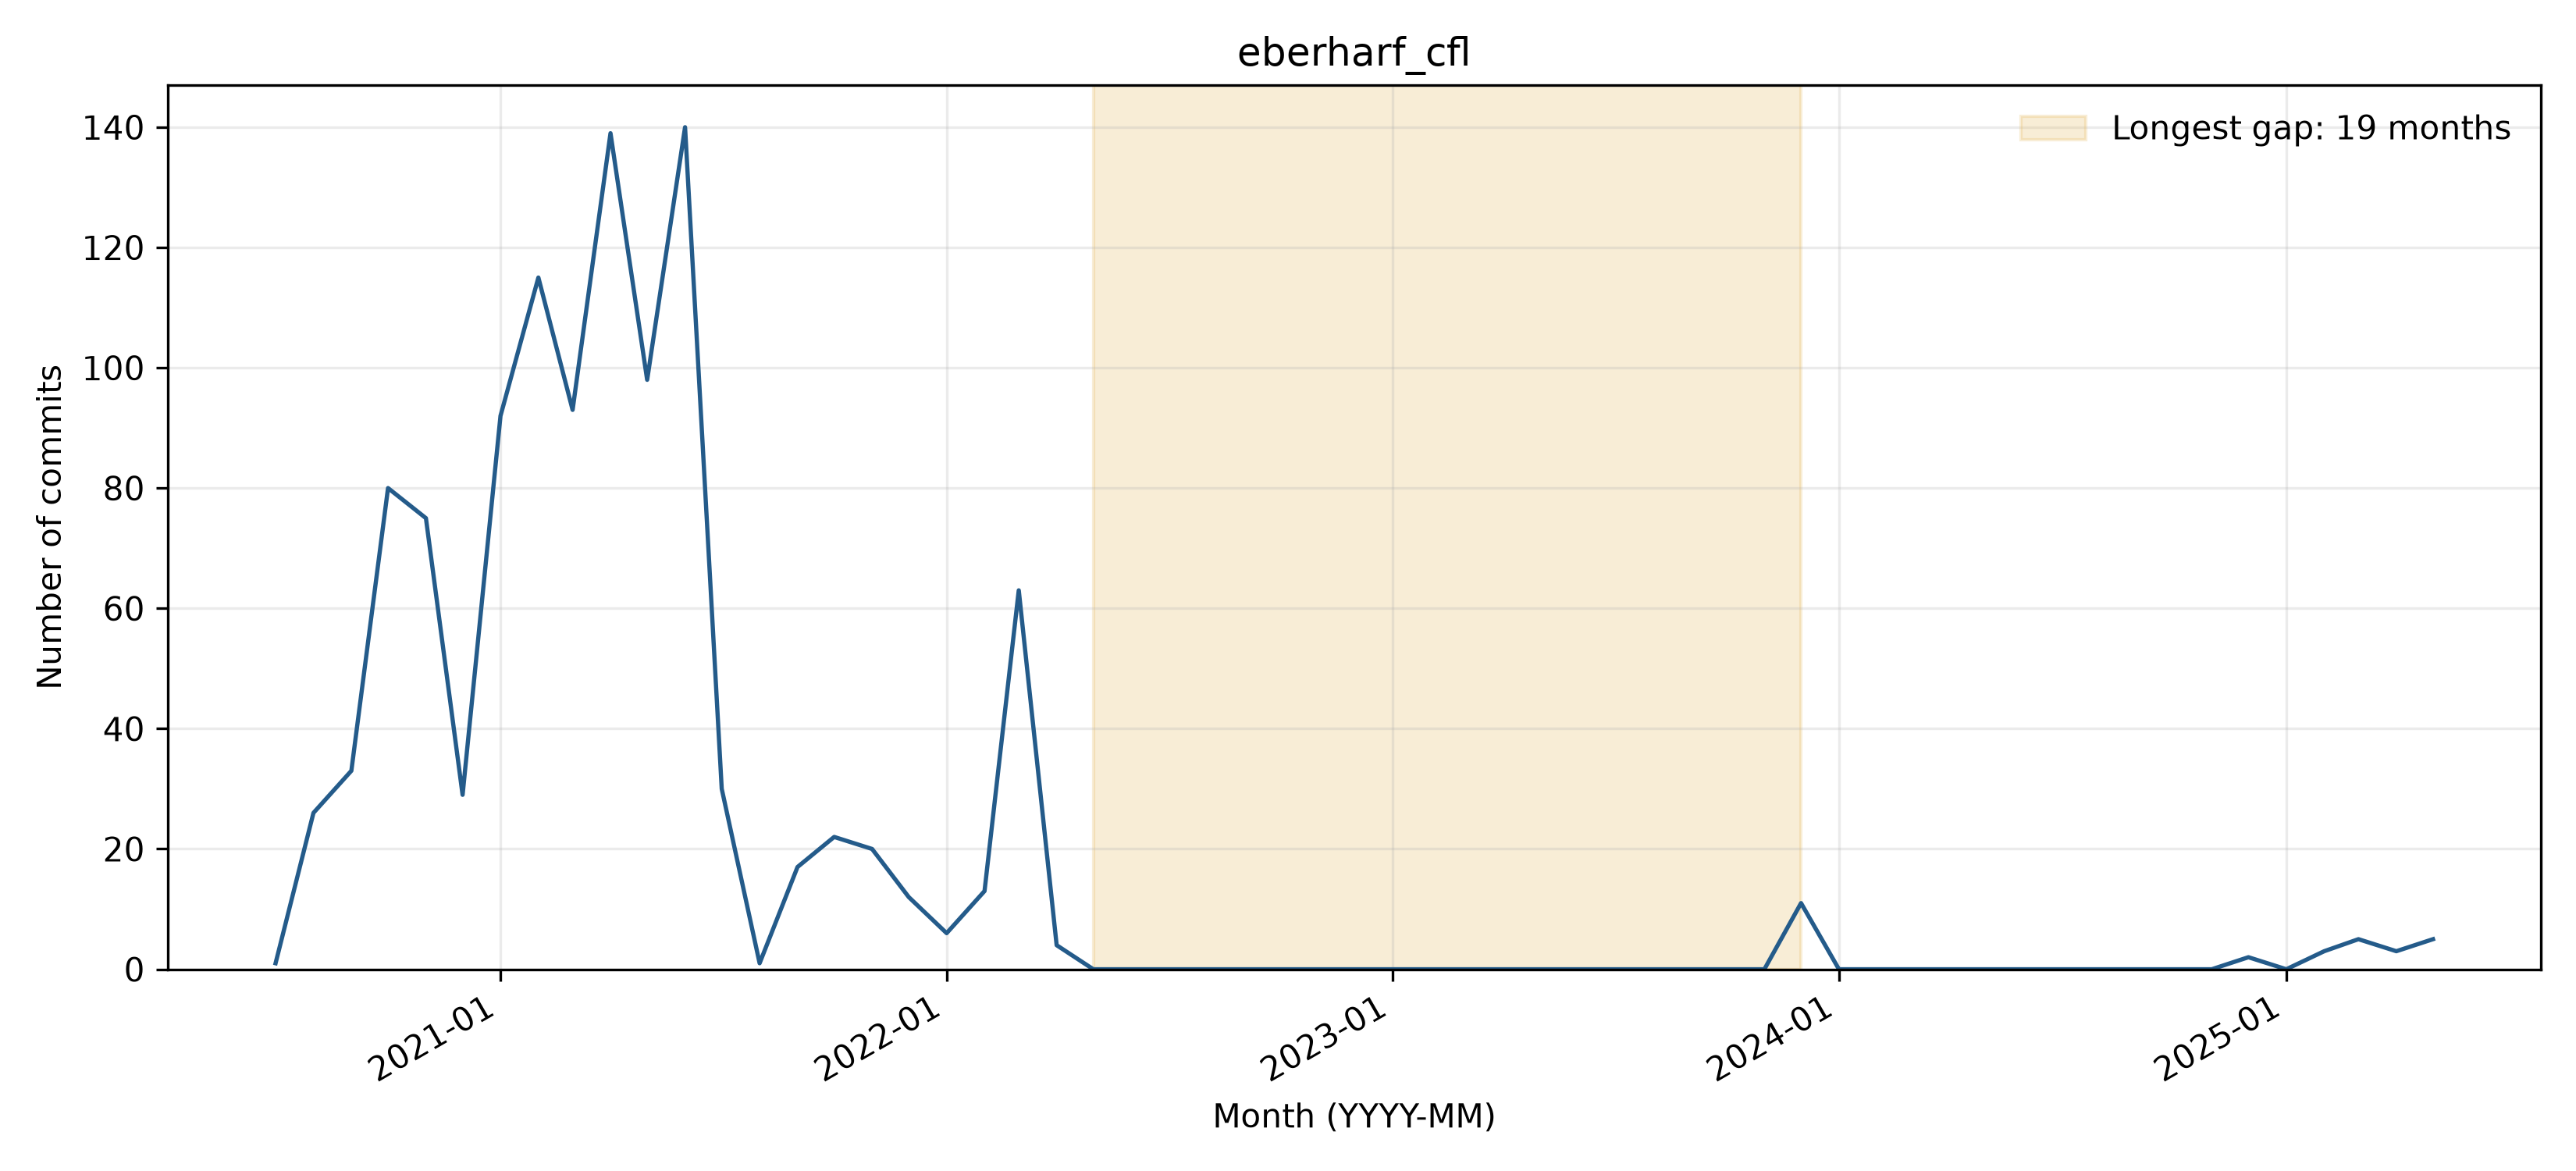

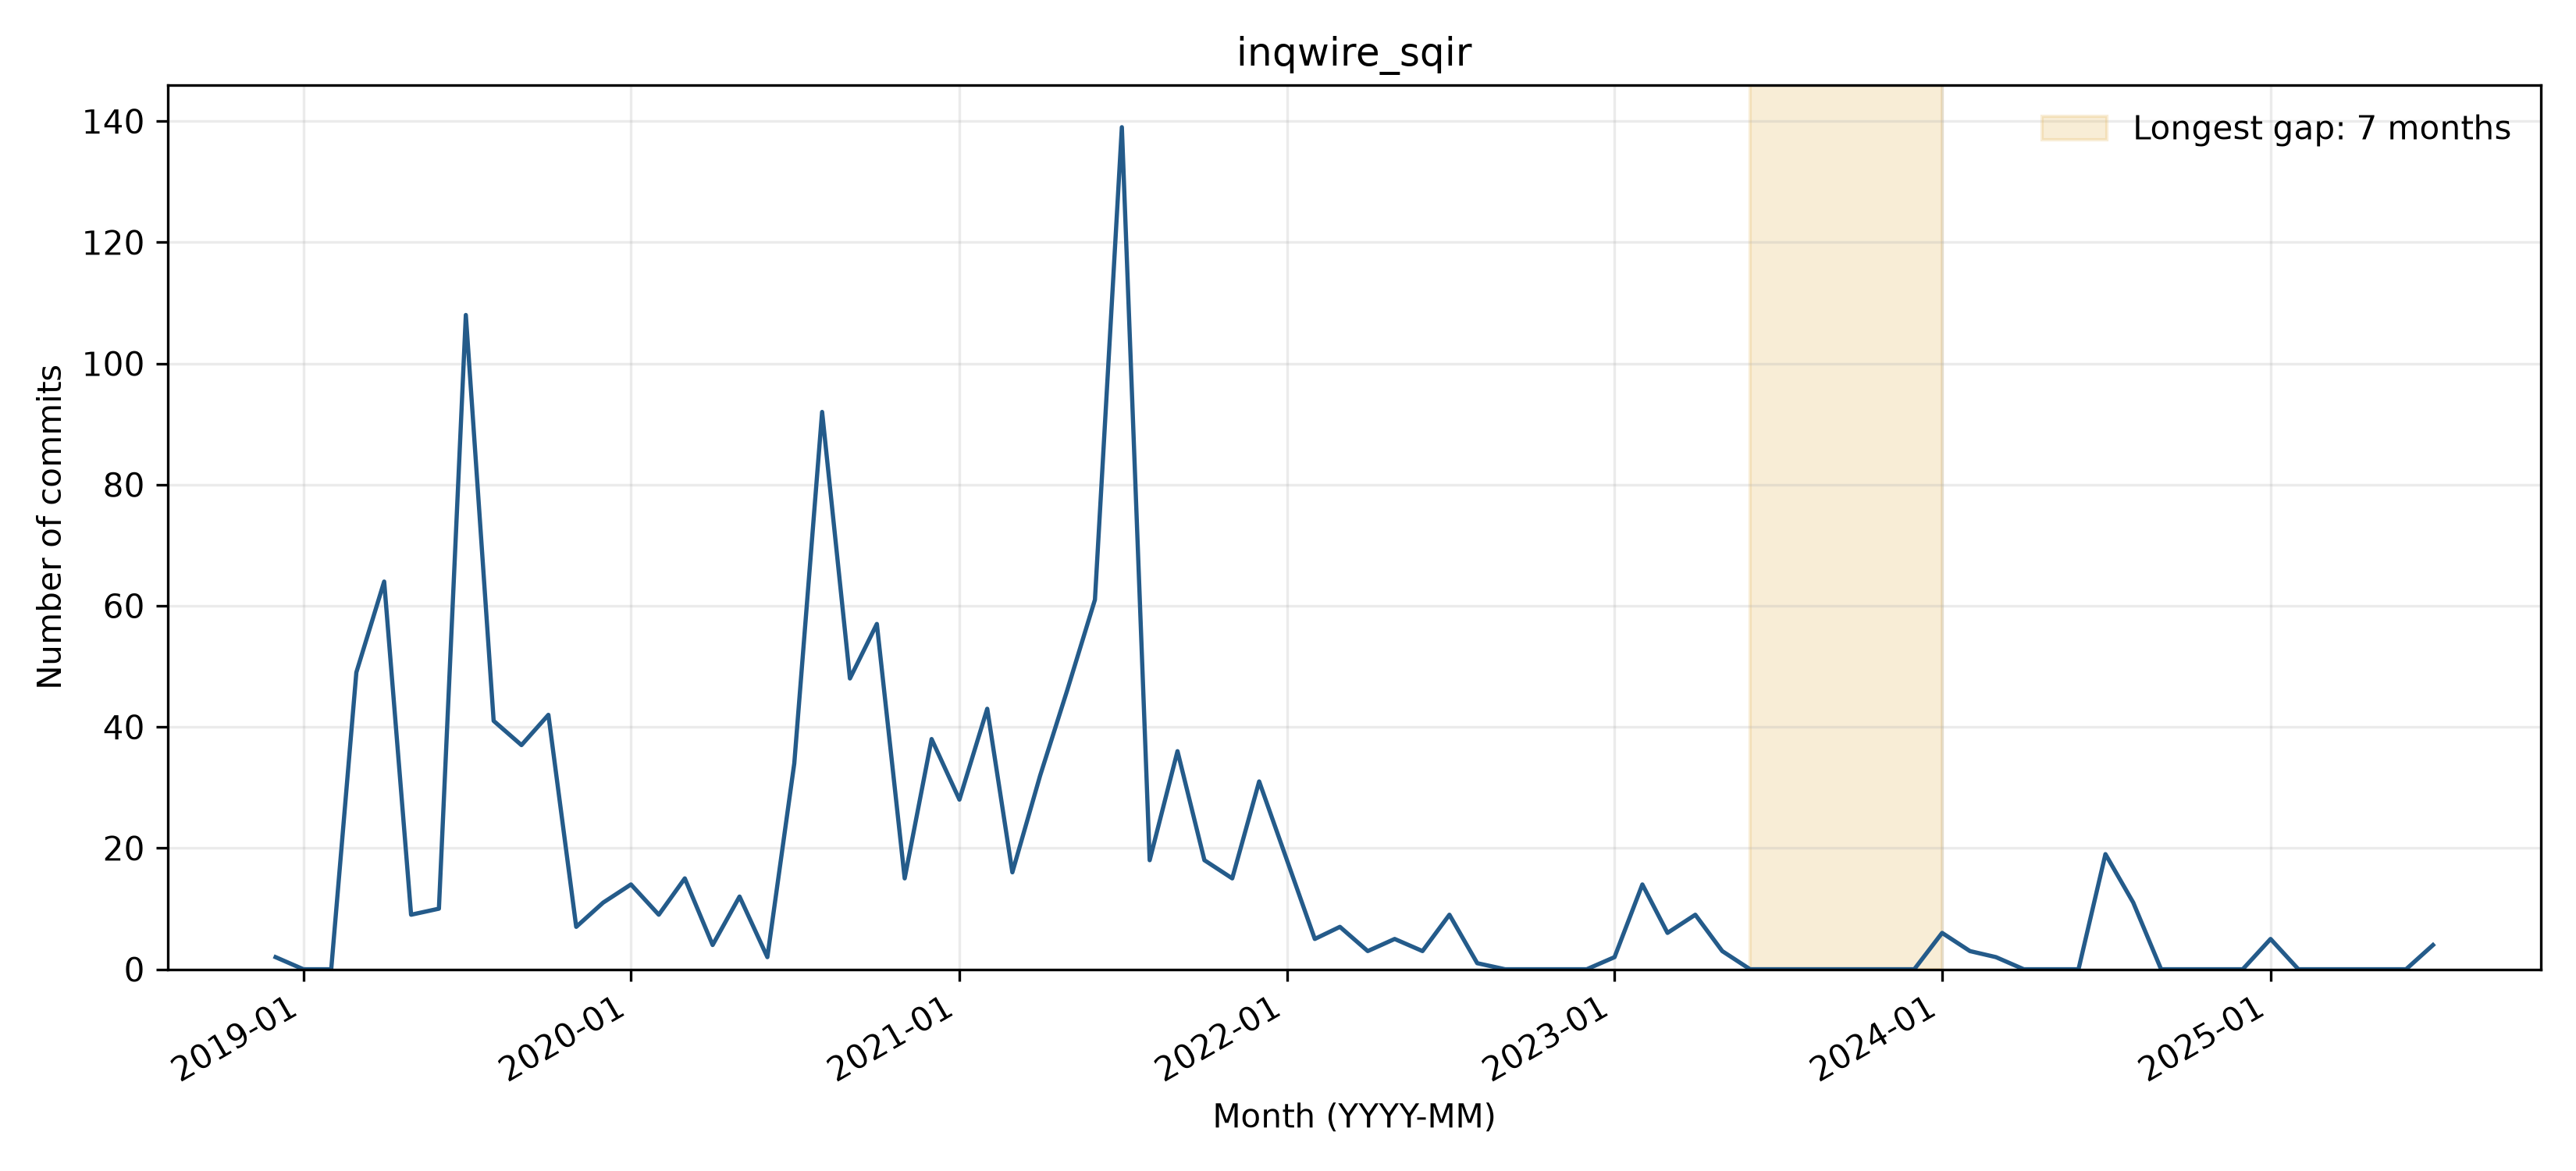

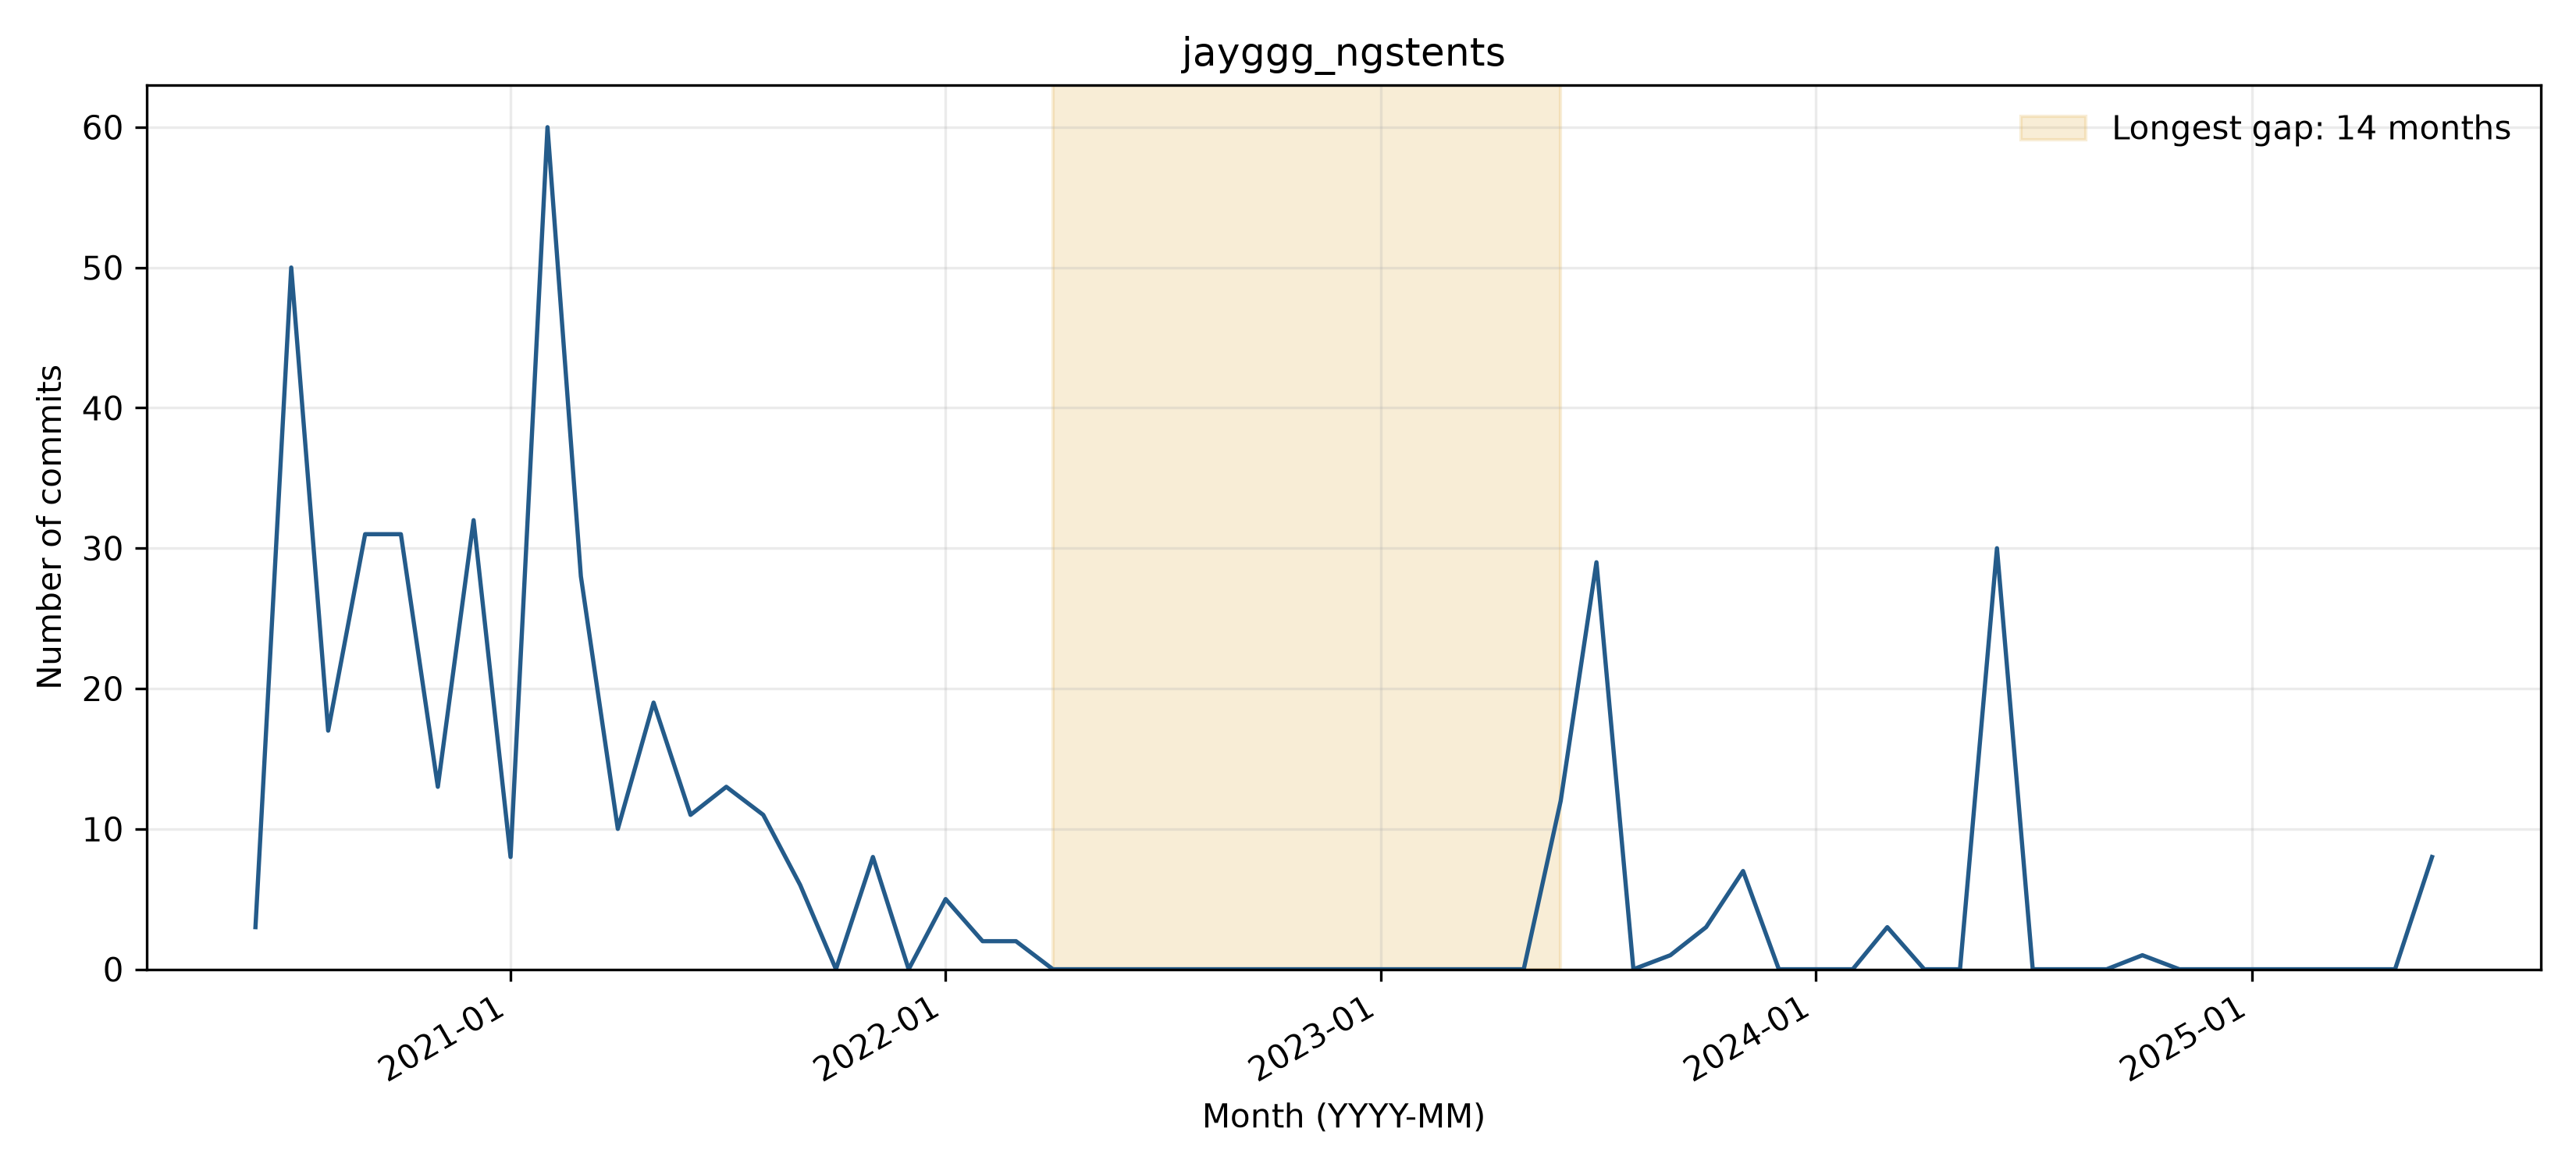

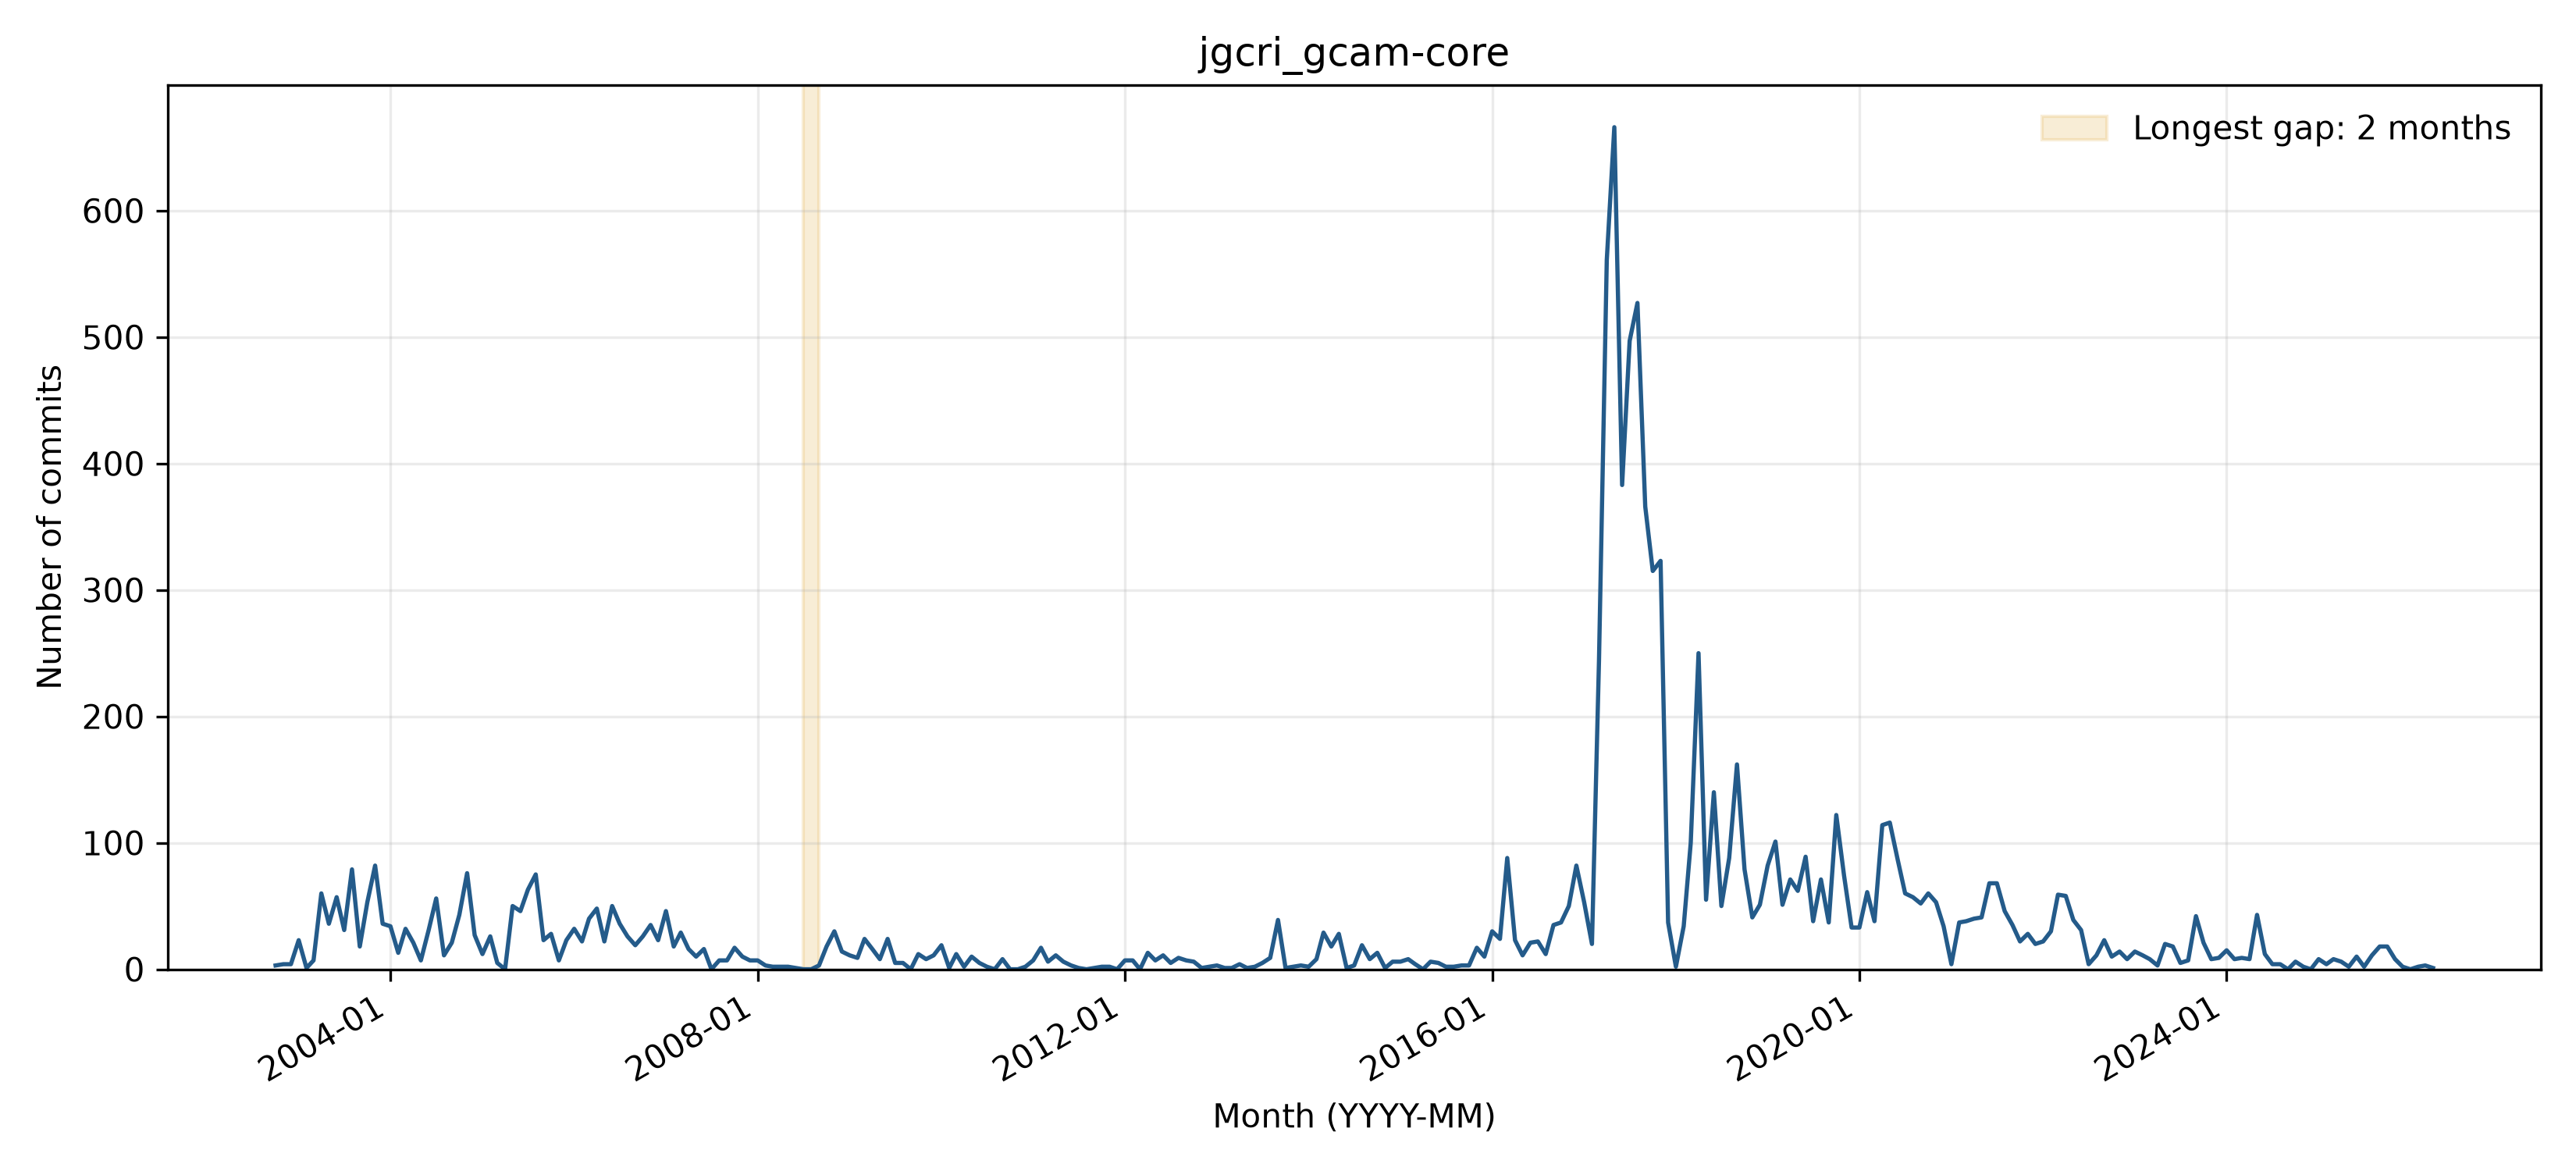

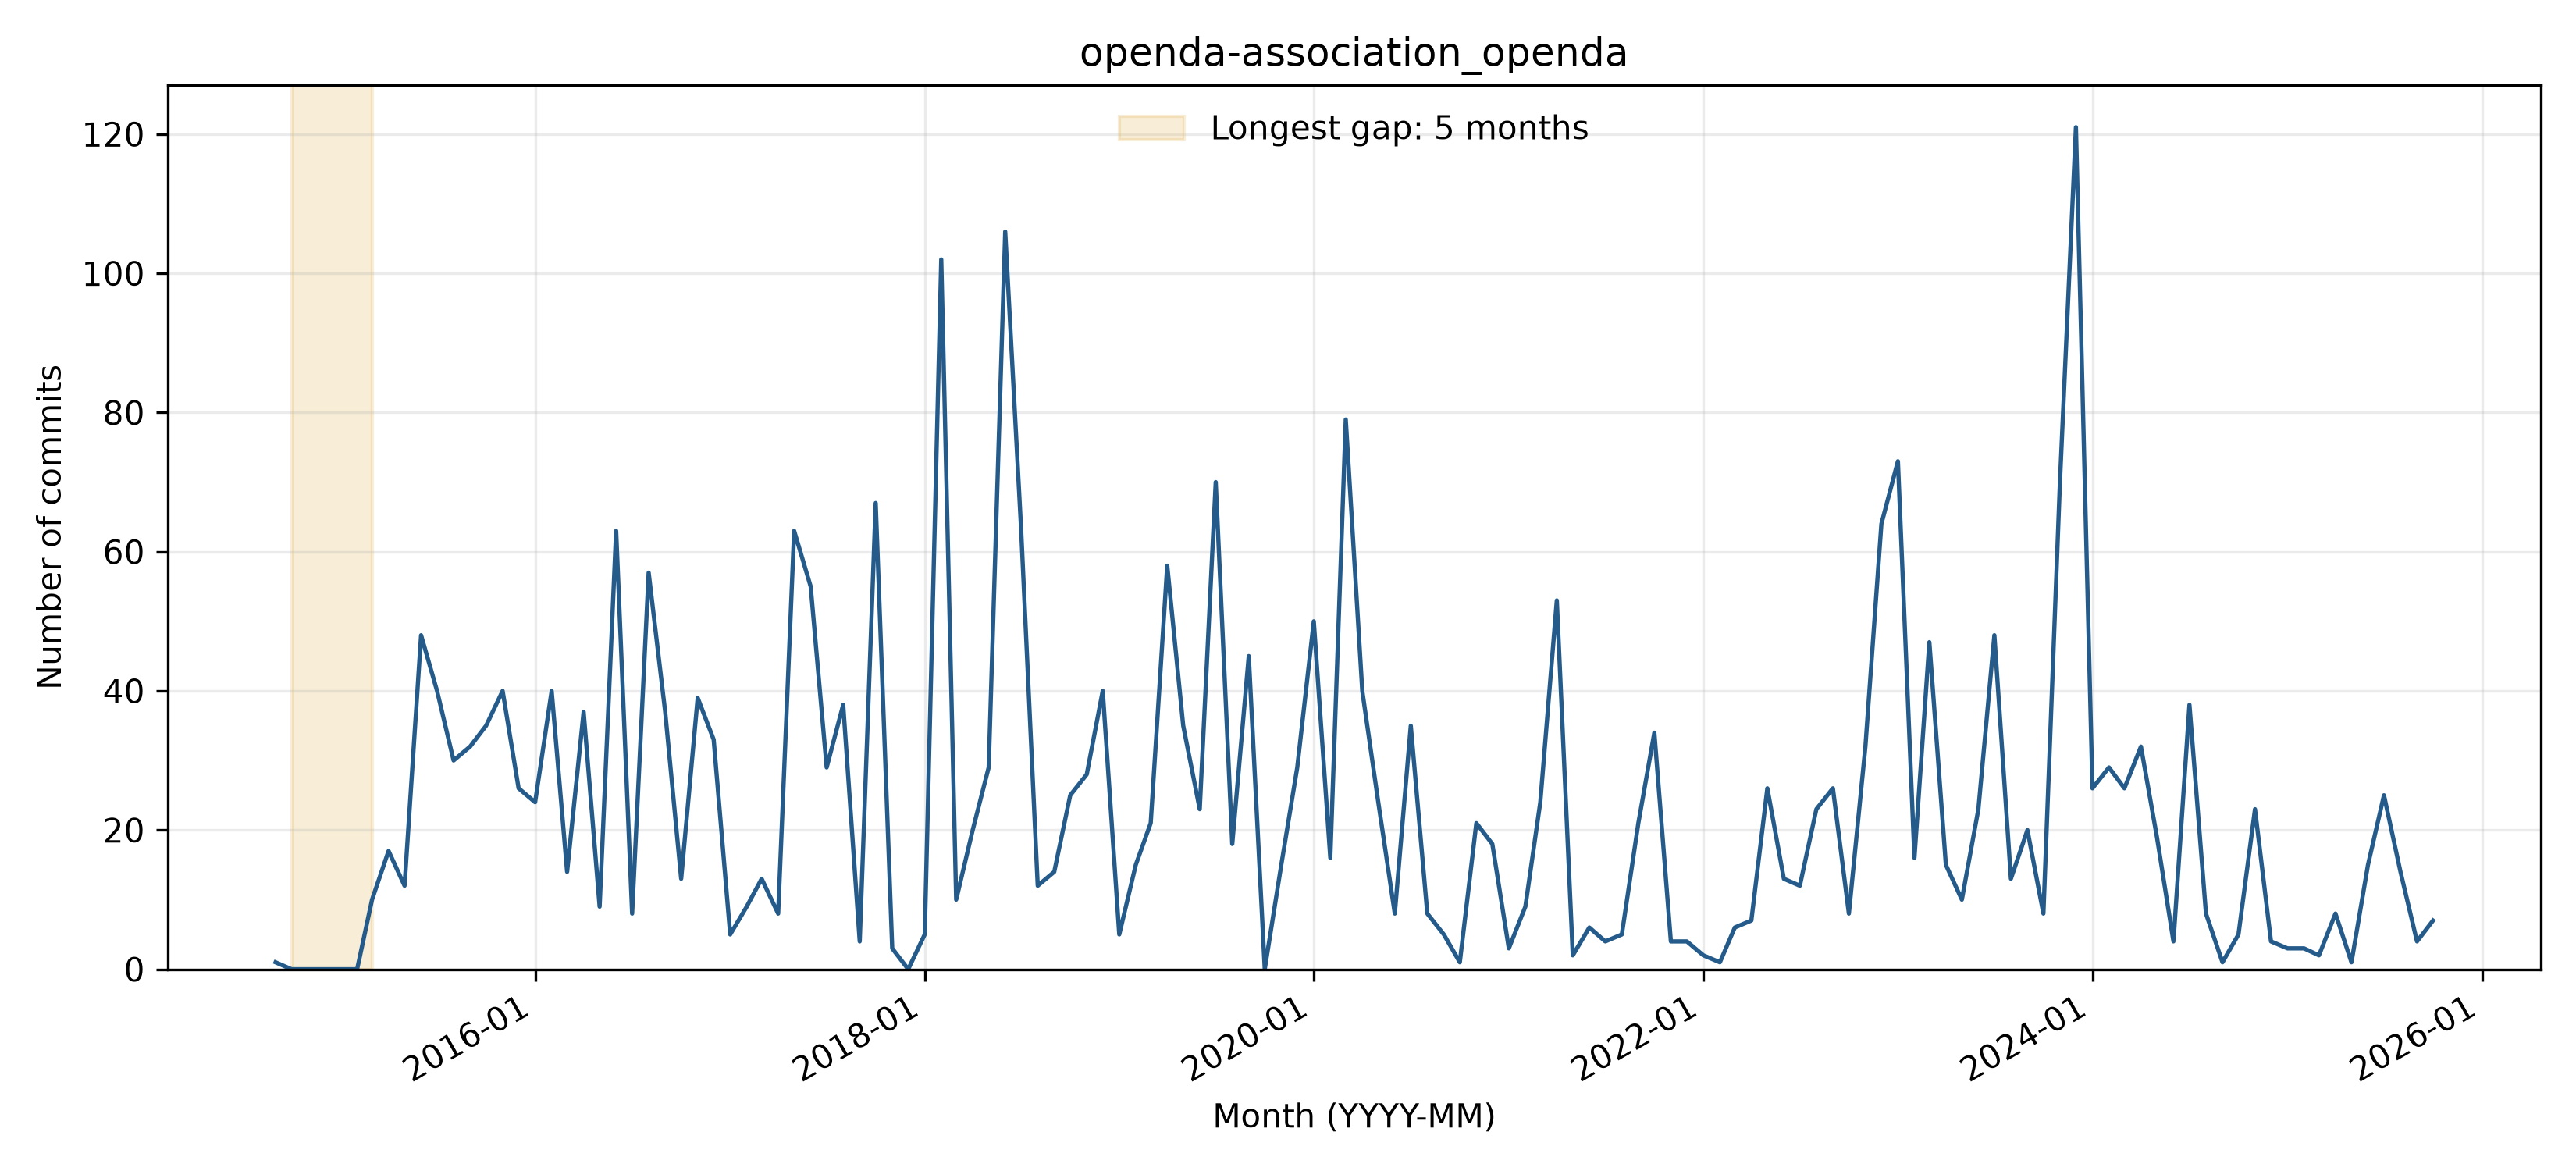

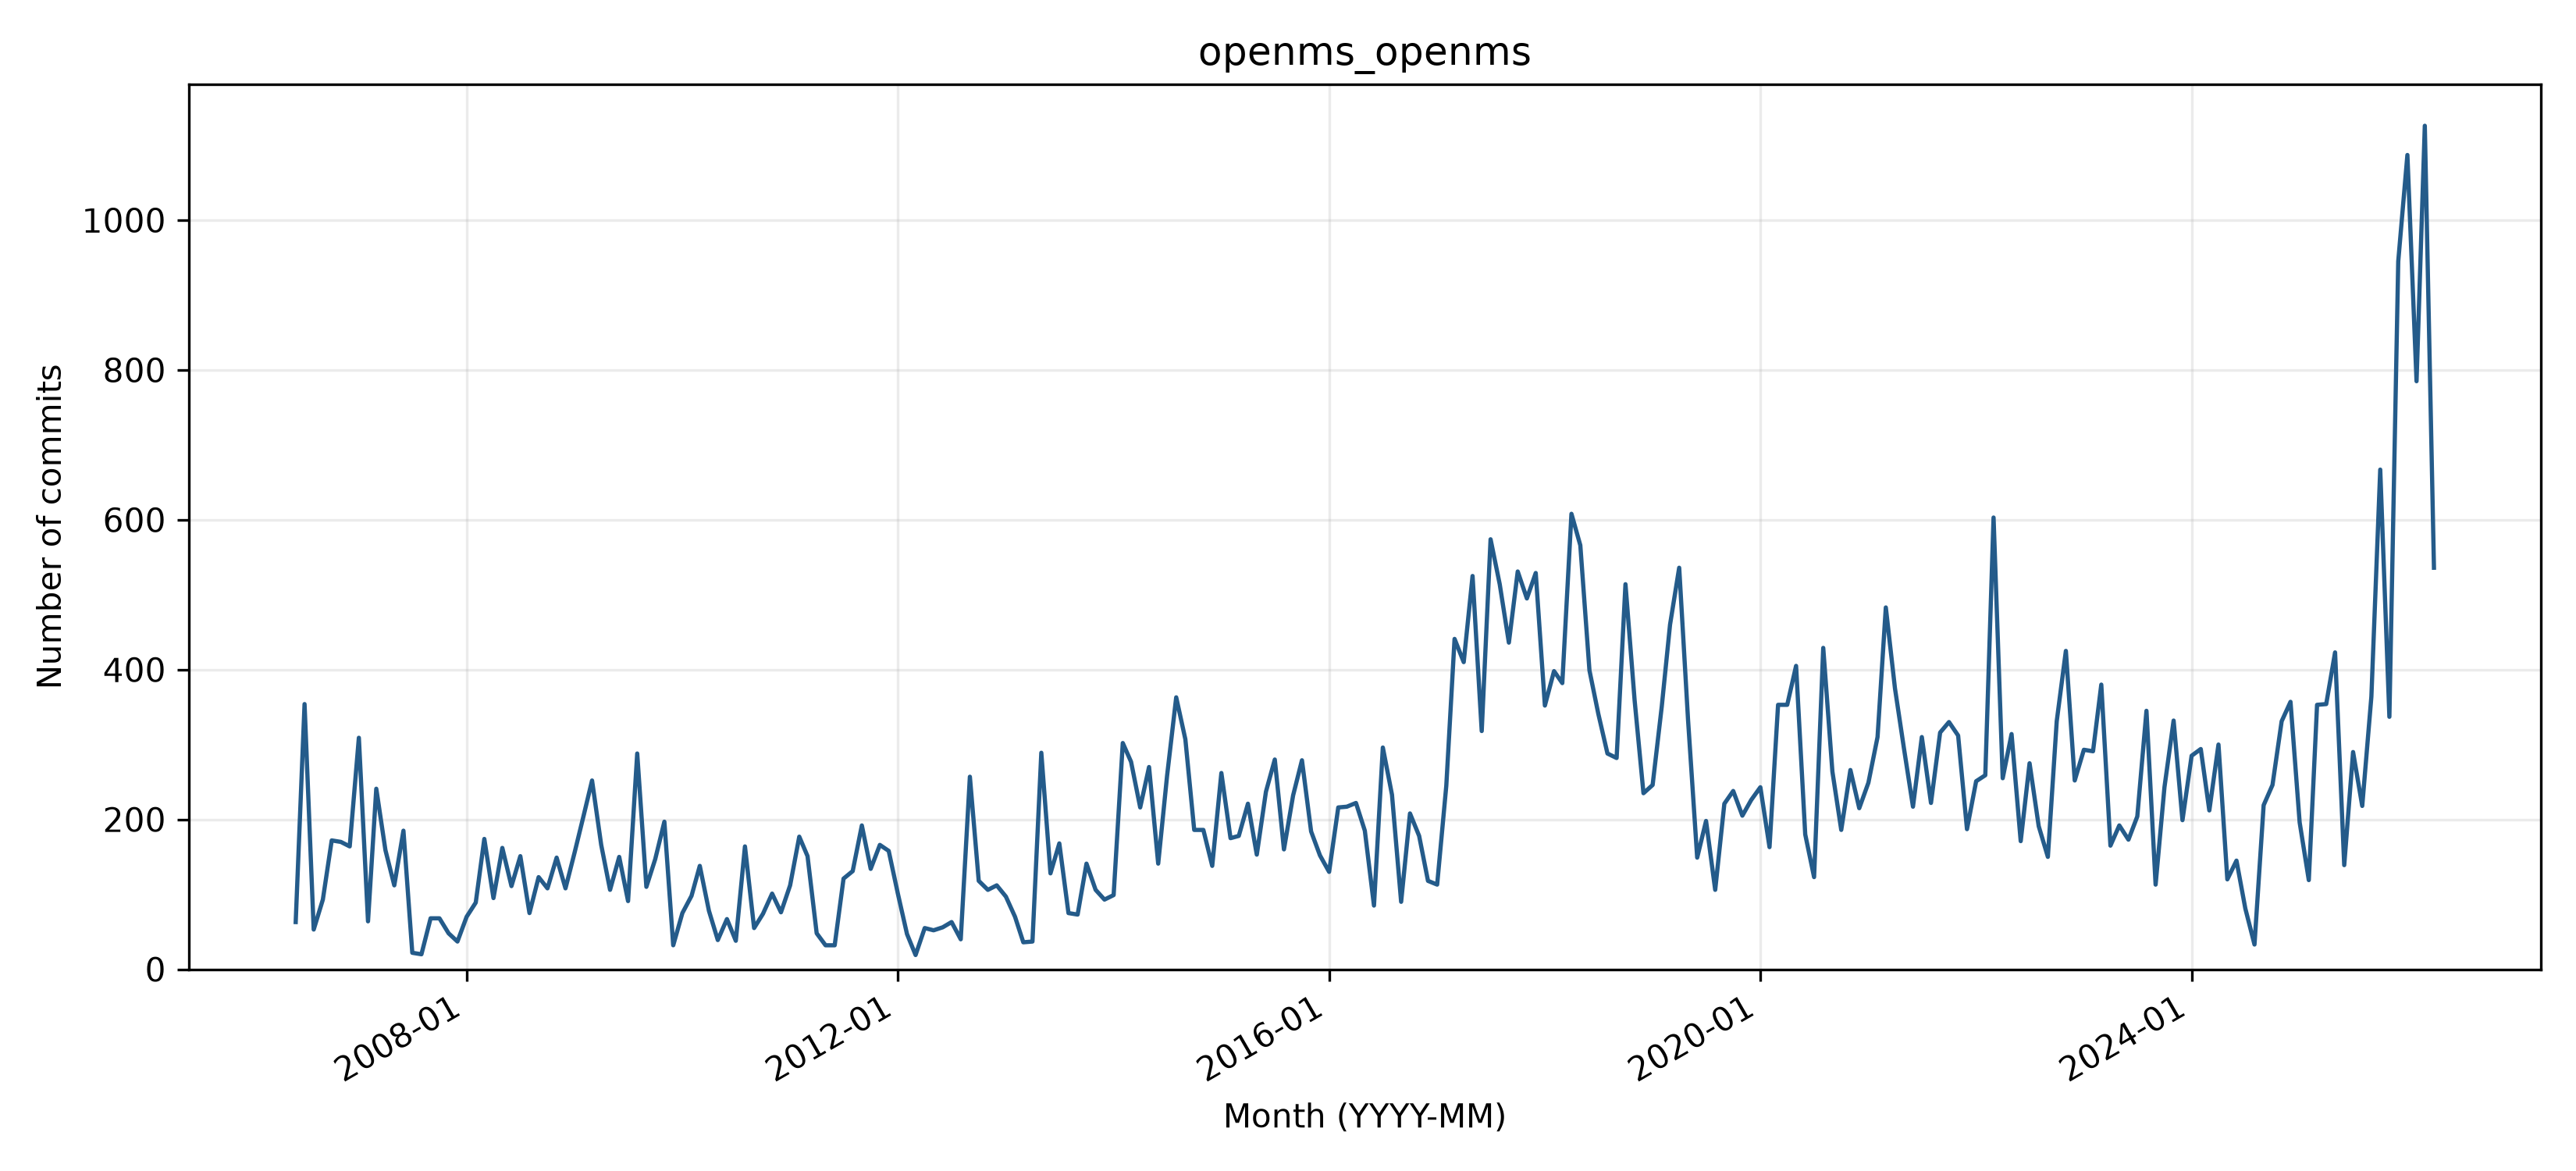

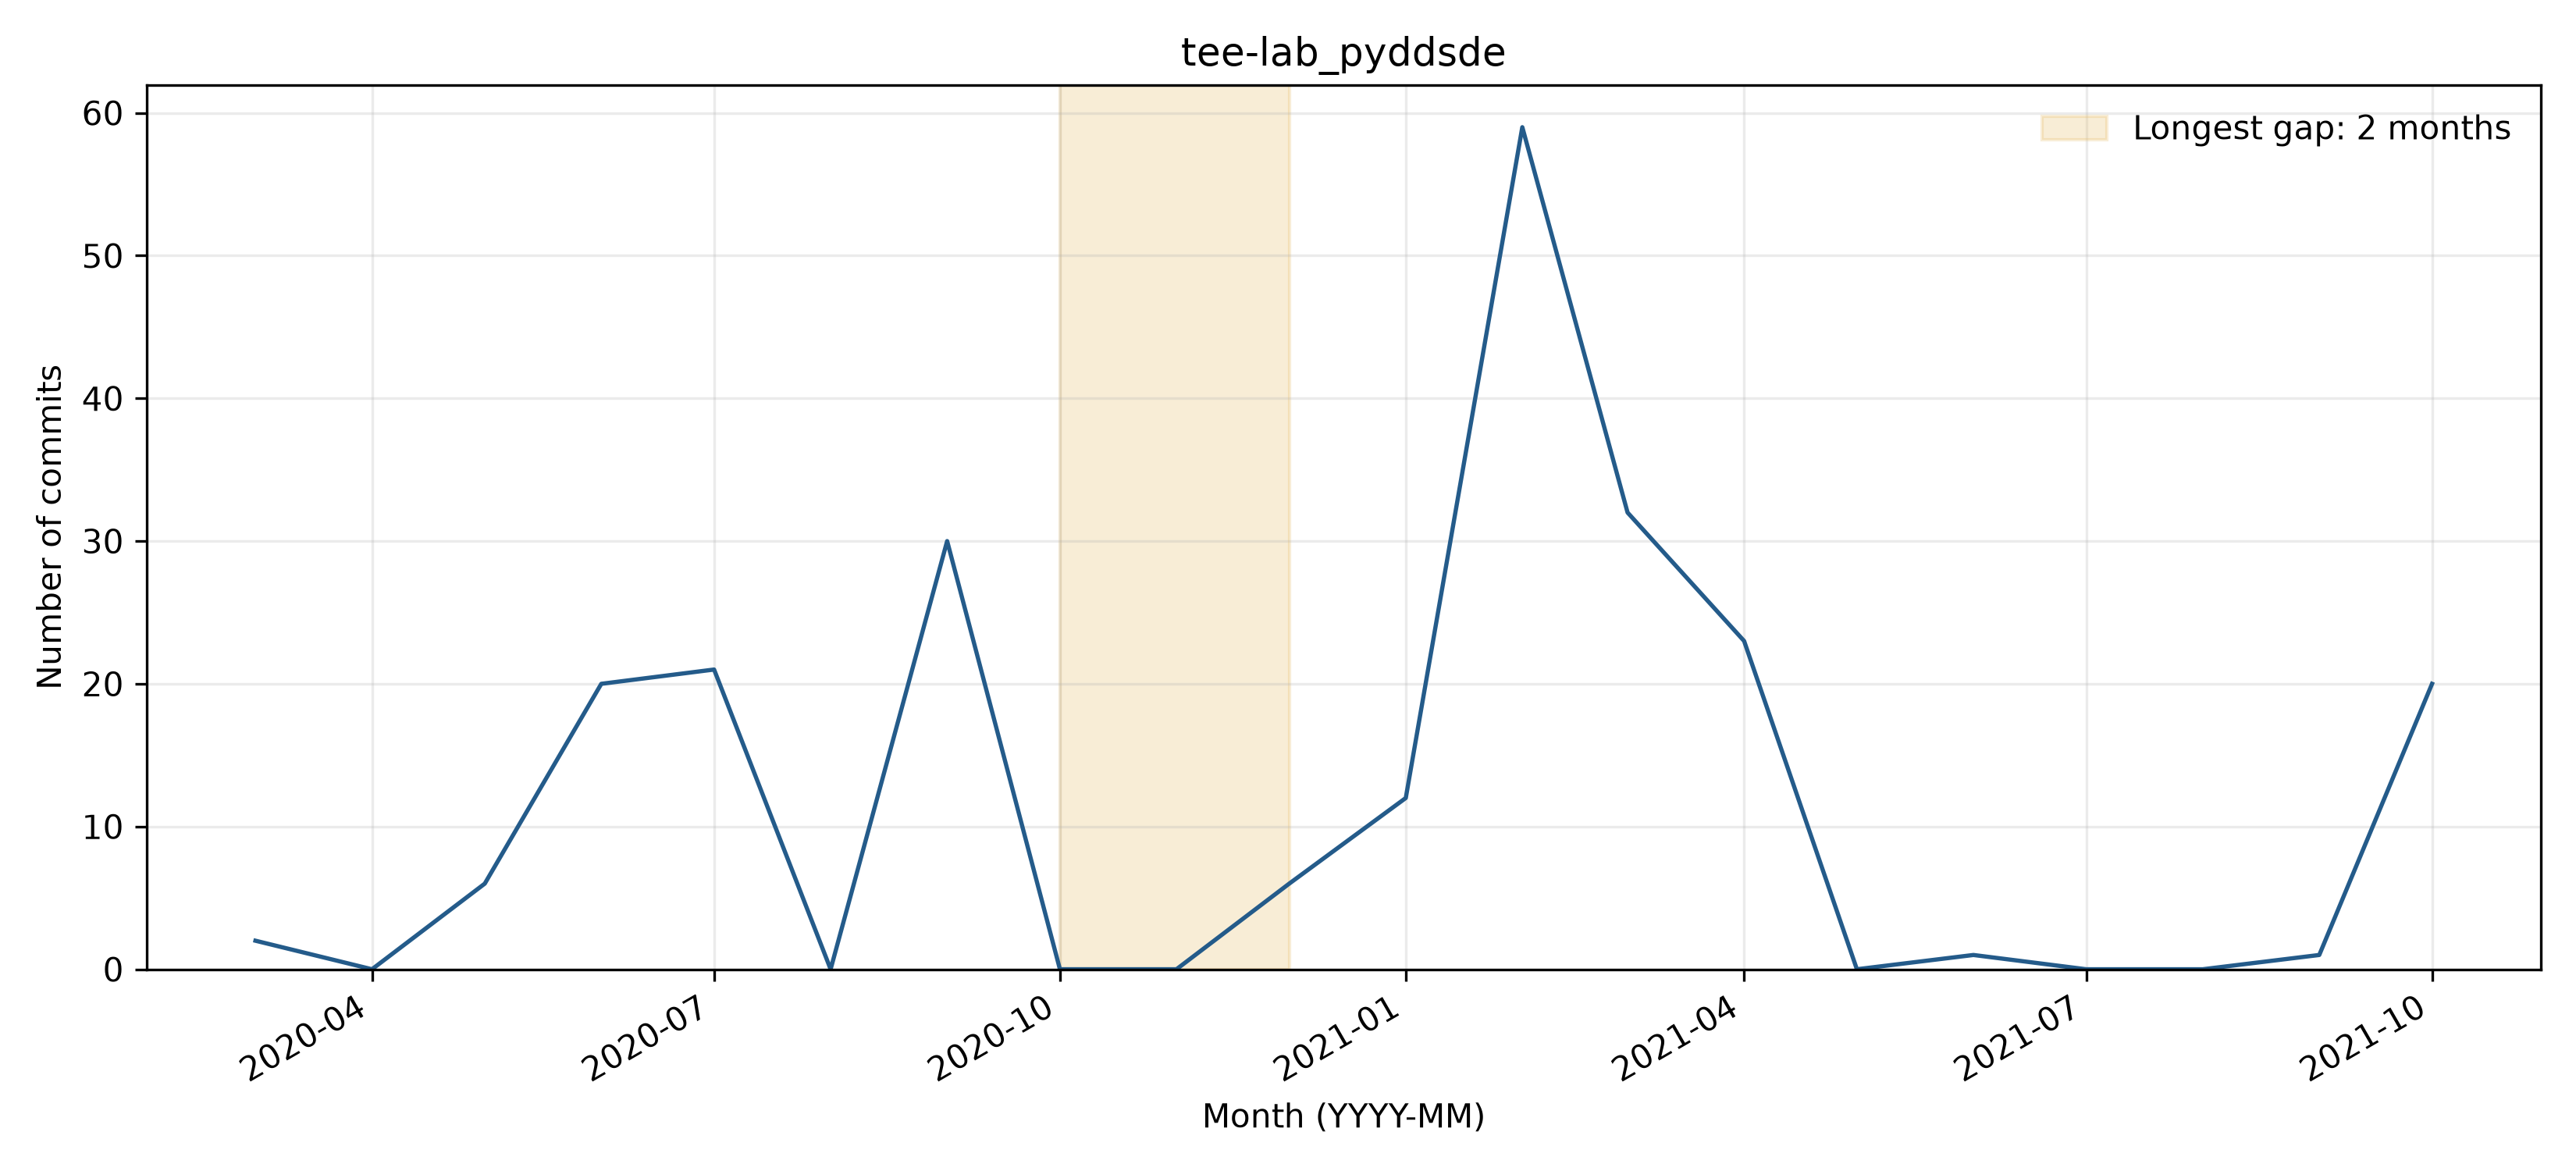

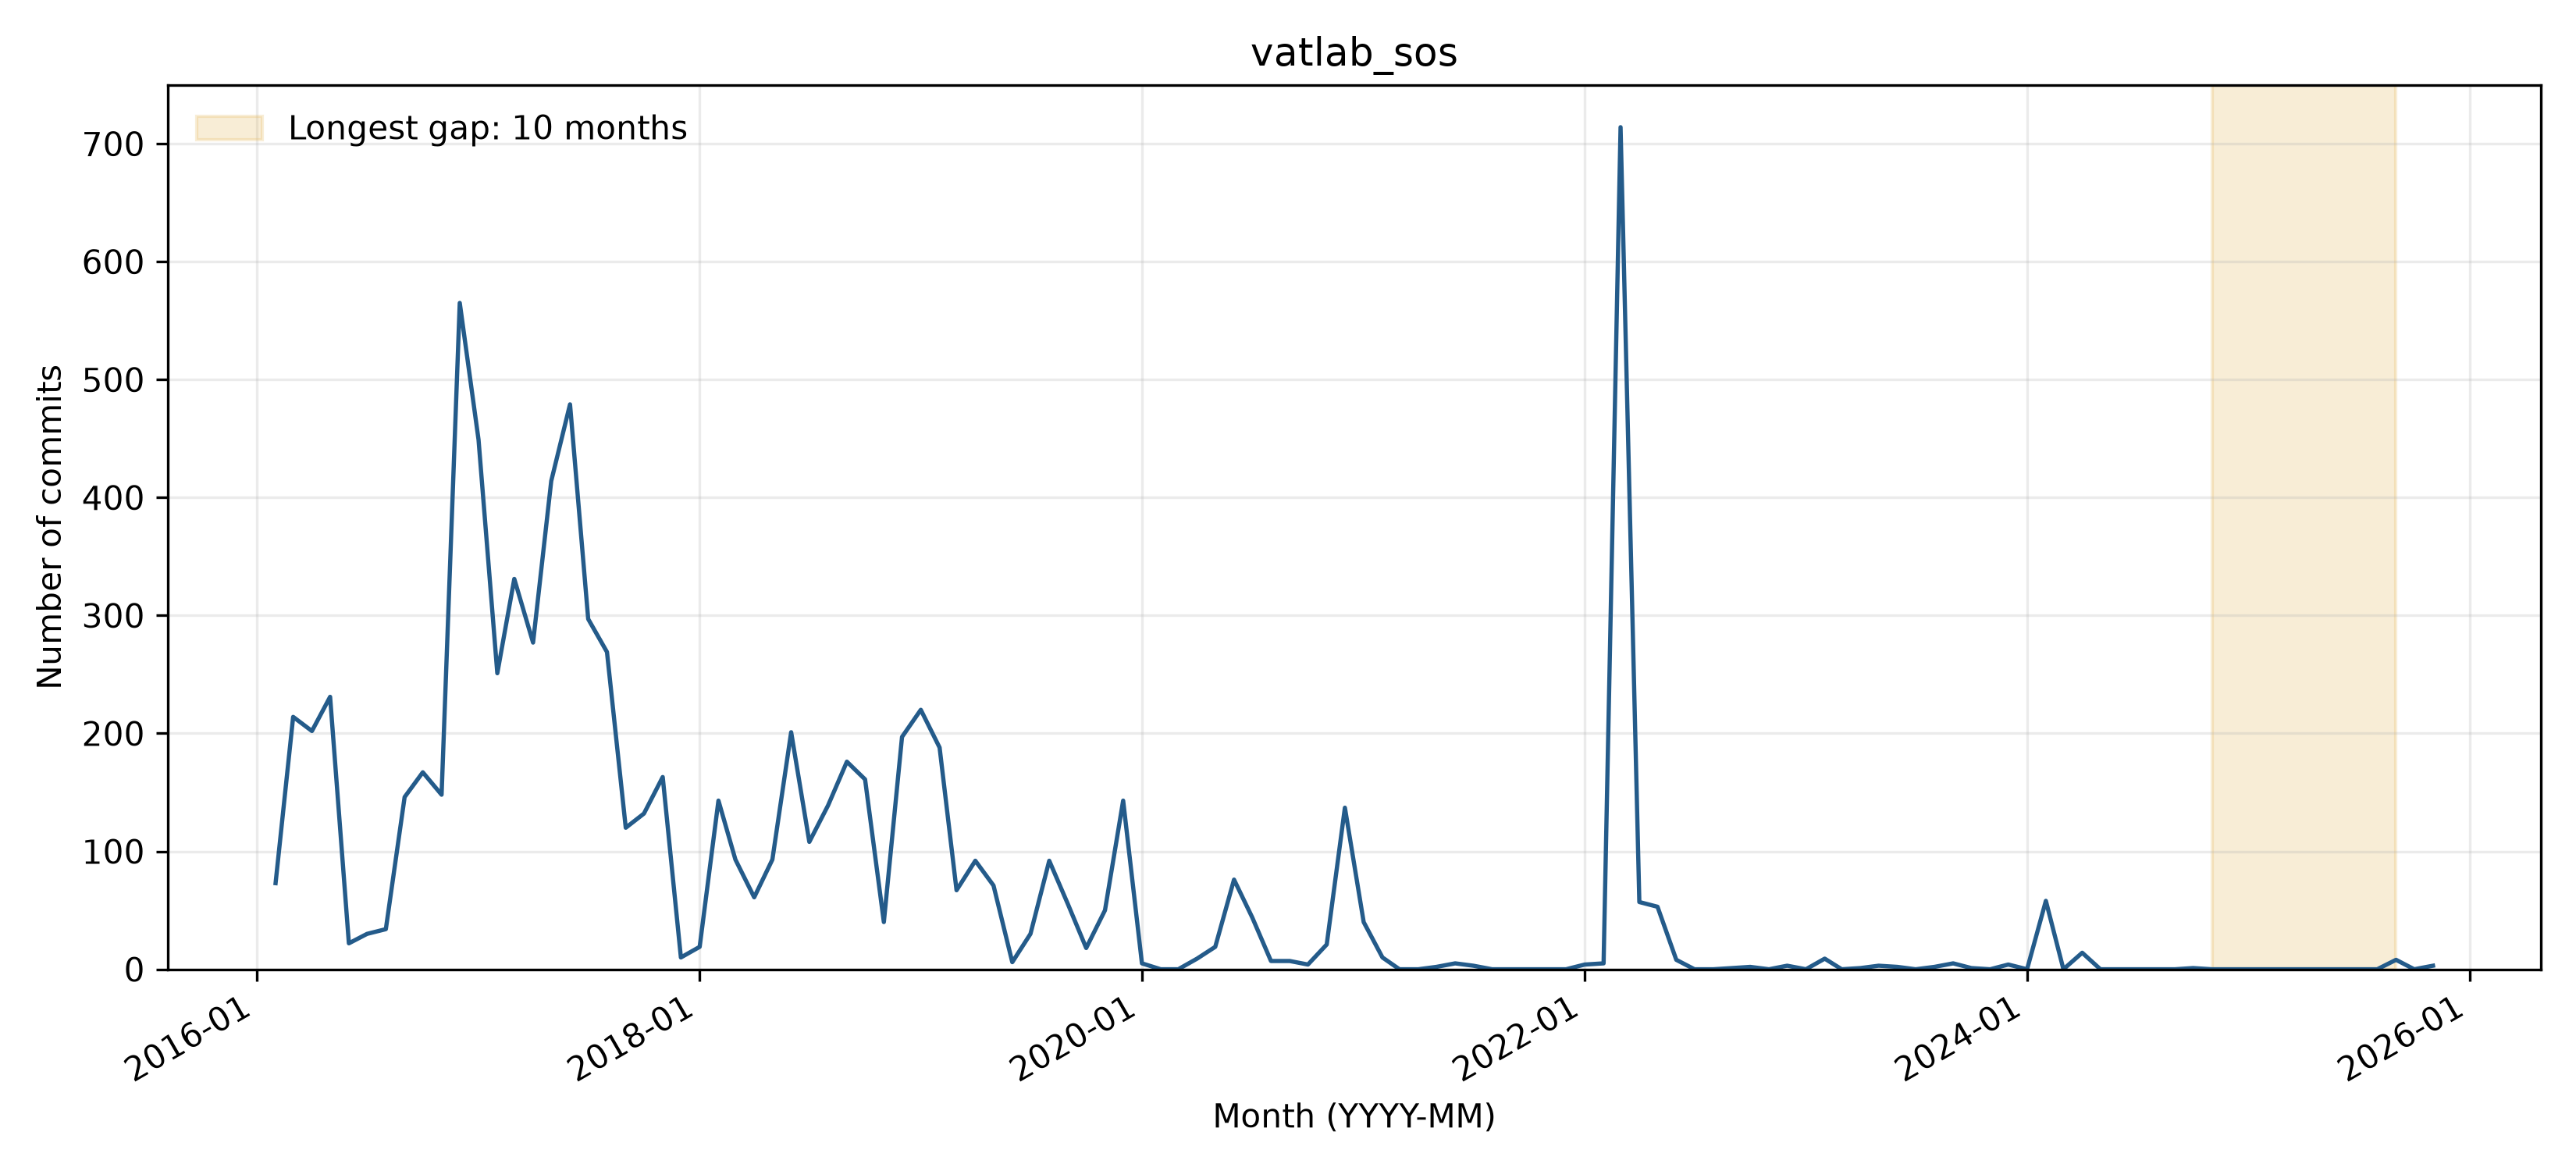

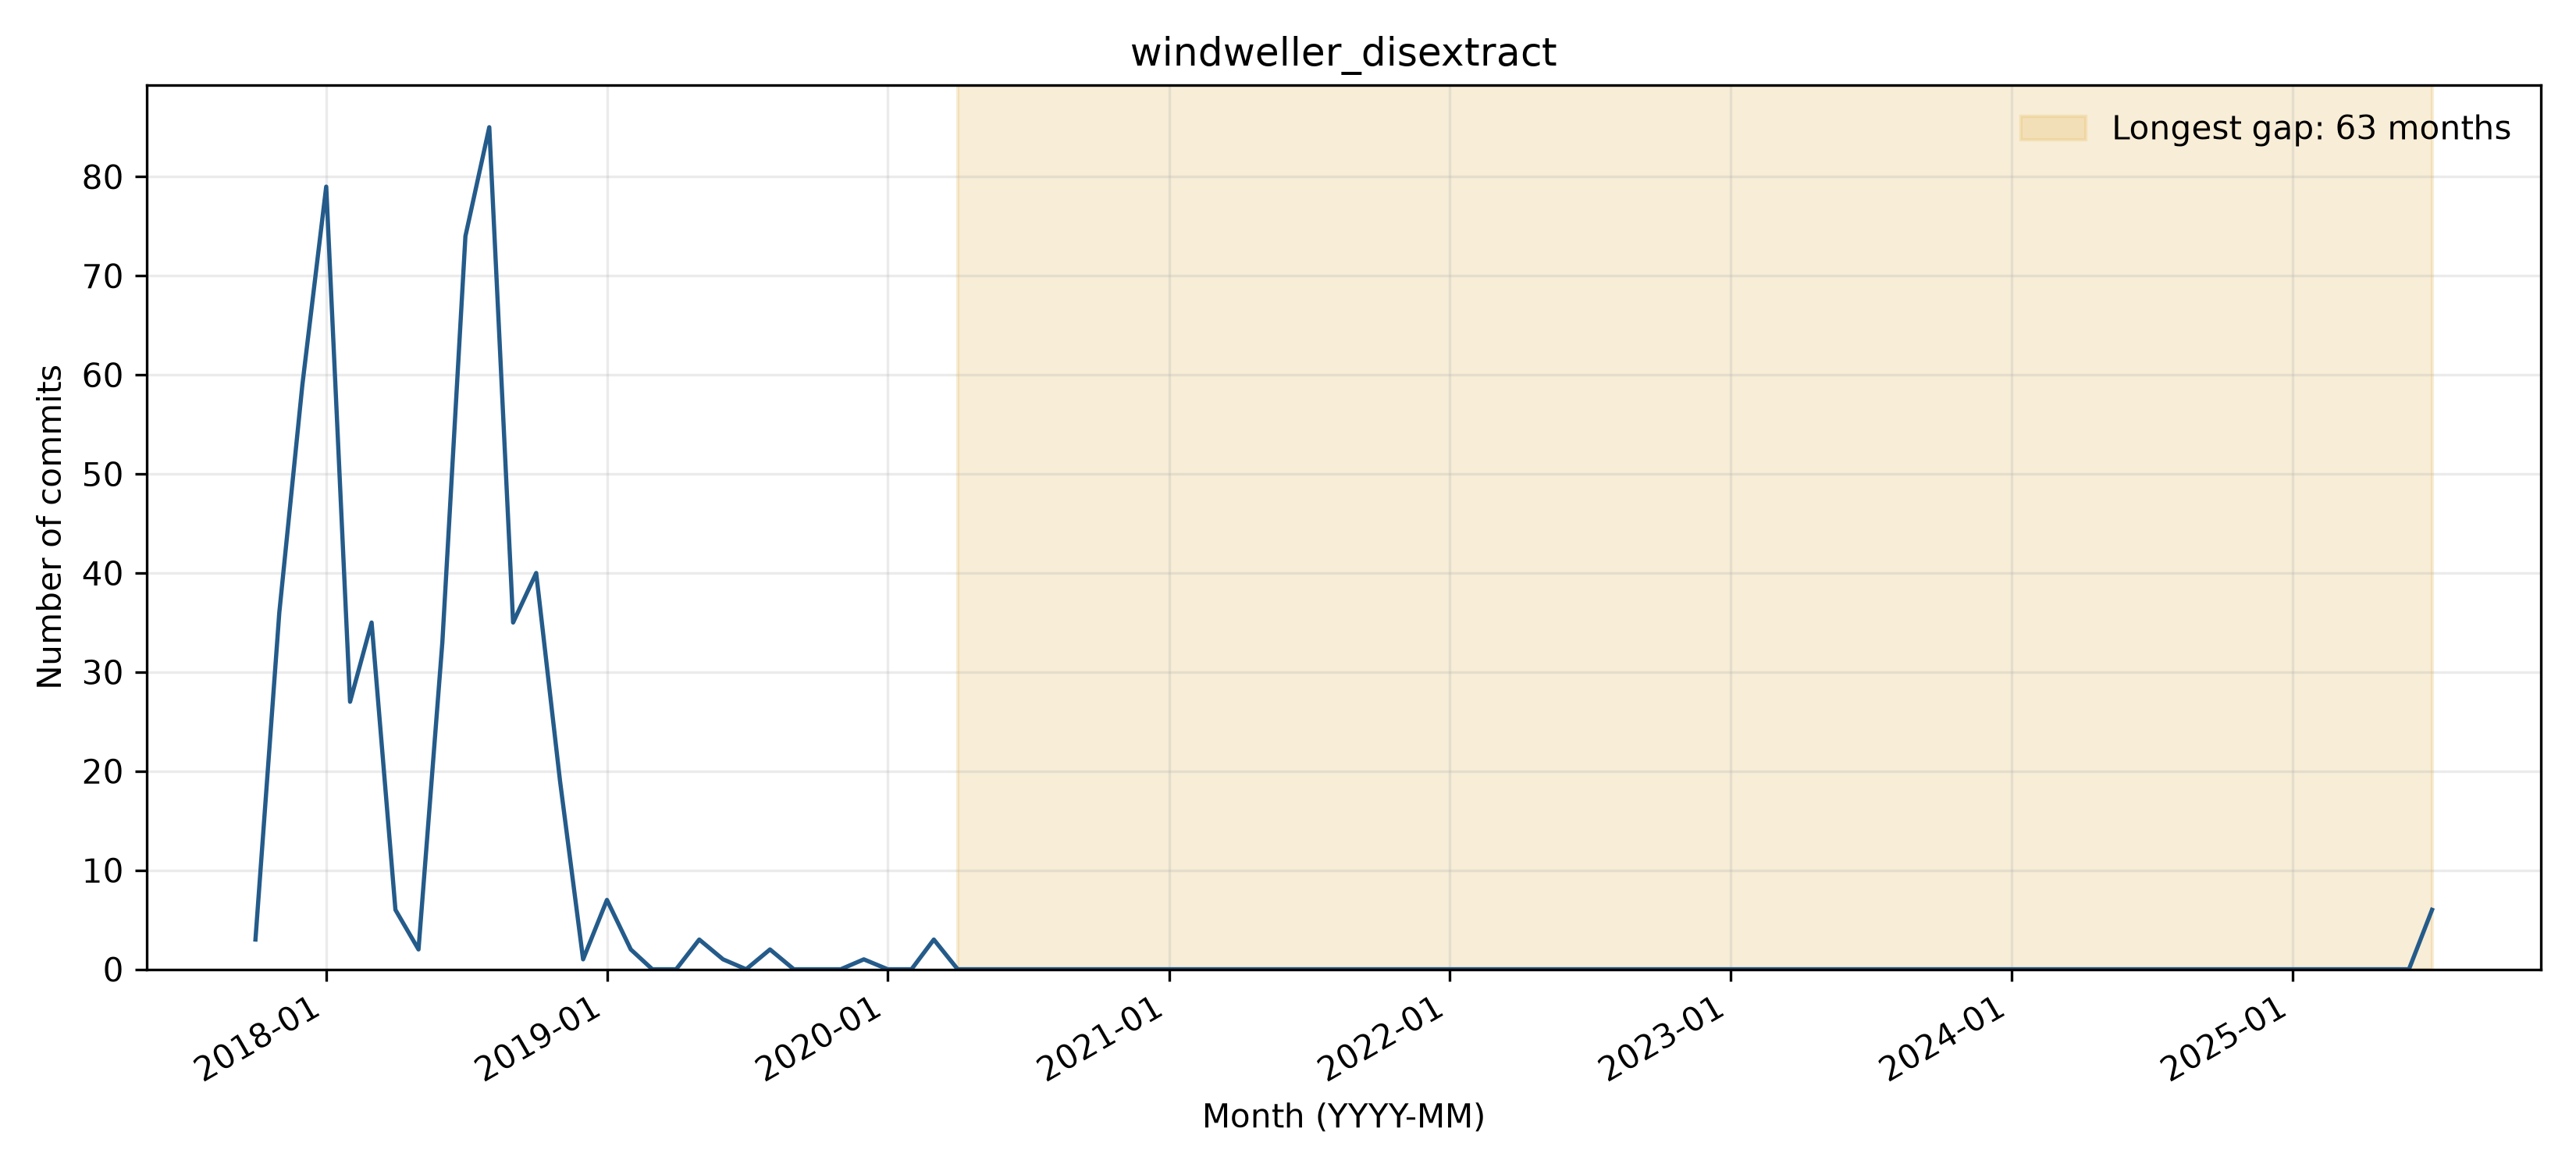

In [3]:
if ready:
    for project in stats['Project']:
        display(Image(filename=str(ROOT / f'{NETID}_timeseries_{project}.png'), width=900))

## Interpretation

All ten projects are analyzed using the available WoC records; 54 unavailable objects are explicitly omitted under the TA-approved approach.

### avehtari_bda_course_aalto

Repeated late-summer/autumn bursts are consistent with the annual course cycle, although their magnitudes vary substantially. The longest gap is February-June 2025, with three gaps of at least three months overall. Automated site-deployment commits contribute heavily to the counts, so this measures repository activity rather than only human editing effort.

### eberharf_cfl

Activity rises to large monthly bursts in early 2021, then falls sharply. The December 2023 restart and scattered 2024-2025 commits remain far below that initial intensity, so the overall trajectory is declining. There are two gaps of at least three months.

### openda-association_openda

Monthly counts fluctuate sharply, with bursts in 2018 and late 2023 and quieter intervening periods, without a clear fixed seasonal cycle. The available-record timeline has one gap of at least three months: October 2014-February 2015. This early gap follows a single repository-setup commit, making it different from a mature project stopping development.

### openms_openms

Every month in the observed June 2006-April 2026 range has at least one retrieved commit. Monthly activity is typically higher after 2013 than in the early years, with especially large late-2025/2026 bursts, supporting a rising overall trajectory despite substantial fluctuations. There are no zero-month gaps and no gaps of at least three months in this observed range.

### vatlab_sos

Typical monthly activity falls substantially after the large 2016-2019 development period. A very large isolated spike in 2022 interrupts this decline, but later activity remains sparse and does not establish a sustained return to the earlier level. Three gaps last at least three months; the longest spans November 2024-August 2025.

### jayggg_ngstents

The strongest activity occurs in 2020 and early 2021, followed by lower activity and long pauses. Later bursts in 2023 and 2024 are smaller and isolated, so declining is a reasonable overall classification. Four zero-month runs last at least three months.

### inqwire_sqir

Large development bursts in 2019-2021 give way to much lower activity from 2022 onward. Small 2024-2025 bursts do not return to the earlier intensity, supporting a declining overall trajectory. Five gaps last at least three months.

### tee-lab_pyddsde

Activity is irregular, with 30 commits in September 2020, a two-month pause, and a larger burst of 59 commits in February 2021. There are zero inactivity gaps of at least three months. The isolated peaks do not establish a recurring seasonal cycle.

### jgcri_gcam-core

The timeline has distinct phases, including an exceptional 2017 burst followed by lower activity and a gradual decline after 2020. This large isolated change and the differing earlier phases make irregular a better overall label than a single steady trend. The longest observed zero-month run is July-August 2008, and there are no gaps of at least three months.

### windweller_disextract

Activity is concentrated in 2017-2018, dwindles to occasional documentation changes, and then stops for 63 months. The six WoC commits on a single July 2025 day represent only a brief return, not a sustained rising trajectory. Two gaps last at least three months.


## Gap evidence and reflections

Each project has a reviewed reflection with commit-message evidence and supplementary GitHub sources where applicable. `bdowlin2_project_stats.csv` contains the reviewed summaries and separate fields for analysis completion, full WoC coverage, expected records, and omitted objects. OpenMS has no observed zero-month gap, so no pre/post samples or recovery claims are invented.

Both notebooks contain their own code and work with the submitted CSVs. Local helpers and retrieval caches are not required for offline execution.

In [4]:
if ready:
    samples = pd.read_csv(ROOT / f'{NETID}_project_gap_commits.csv', sep=';', keep_default_na=False)
    display(samples)
    print('Boundary samples cover the nine projects with observed gaps. OpenMS has no observed gap. All ten reflections are reviewed.')

,pre/post,project_wocid,commit_sha1,author,time,commit message
0,pre,avehtari_bda_course_aalto,7c88a18ab057716bb9bbfb7191f57b74acd6ebaa,Quarto GHA Workflow Runner <quarto-github-acti...,1732803947,Built site for gh-pages\n
1,pre,avehtari_bda_course_aalto,1c48cfdd5a5b212e4de259821d9d51d3b0b52fdb,Aki Vehtari <Aki.Vehtari@aalto.fi>,1732804403,updated instructions and minor fixes\n
2,pre,avehtari_bda_course_aalto,1b987c7089b5de9ecbad74a97eb8fe054aa3acec,Quarto GHA Workflow Runner <quarto-github-acti...,1732804672,Built site for gh-pages\n
3,pre,avehtari_bda_course_aalto,af8c45e10eed0511ffae84102f54a2bf98257c8a,davkoh <53530807+davkoh@users.noreply.github.com>,1733311087,Update of project feedback deadline
4,pre,avehtari_bda_course_aalto,629fa637a4c9cd631d50e89fa8d70adf95ab9903,Quarto GHA Workflow Runner <quarto-github-acti...,1733311370,Built site for gh-pages\n
...,...,...,...,...,...,...
162,post,windweller_disextract,4c3984ea3c0326d38d54f9ef8aa2292e2b2ad9ee,testtt7272 <testtt7272@gmail.com>,1752416950,Add files via upload
163,post,windweller_disextract,acee584fac9fd411f00d9534c56435cf176a50af,testtt7272 <testtt7272@gmail.com>,1752418089,Update bookcorpus.py
164,post,windweller_disextract,5f316e00ebf1cffbd42b8e0af1cb653d030983d4,testtt7272 <testtt7272@gmail.com>,1752418455,Update bookcorpus.py
165,post,windweller_disextract,d06b29318aab45e920295d2803cc7aadc922e5d8,windweller <testtt7272@gmail.com>,1752419432,Update bookcorpus.py


Boundary samples cover the nine projects with observed gaps. OpenMS has no observed gap. All ten reflections are reviewed.
